<a href="https://colab.research.google.com/github/anupat2046/anupat2046-AI-vs.-Human-Content-Detection-End-to-End-Classification-Model-/blob/main/ai_human_content_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 : Introduction

**About Dataset**

**Dataset:** AI vs Human Content Detection Dataset (Synthetic Dataset)

**Source:** Kaggle

**Overview**

ข้อมูลชุดนี้เป็นชุดข้อมูลที่รวบรวมข้อความมากกว่า 1,000 รายการ ซึ่งแต่ละรายการจะถูกระบุไว้ว่าเป็นข้อความที่เขียนโดย  AI หรือเป็นข้อความที่มนุษย์เขียนขึ้น โดยมีฟีเจอร์ทางด้านภาษาต่างๆ ที่ทำให้สามารถแยกความแตกต่างระหว่างการเขียนของ AI และมนุษย์ได้ นอกจากนี้ข้อมูลชุดนี้ยังมี Label ที่ชัดเจน (AI / Human) และมีฟีเจอร์ที่หลากหลาย ครอบคลุมทั้งเชิงเนื้อหาและเชิงรูปแบบ จึงเหมาะสำหรับการสร้างโมเดล Machine Learning ประเภท Classification เพราะโมเดลสามารถเรียนรู้ความสัมพันธ์ระหว่างฟีเจอร์และ Label ได้อย่างดี

**Total Features:** 17 features

**Total Values:** 1,367 unique values

**Target Variable:** label (1 = AI-generated, 0 = Human-written)

#Part 2 : Data Exploration & Cleaning

##Import Libraries & Setting



 เตรียมเครื่องมือทั้งหมดที่จะใช้ทำโมเดลจำแนกข้อความ (Text Classification) ทั้งสาย ML ทั่วไป, Deep Learning และ Transformers

- **Basic & Visualization**
  - `numpy`, `pandas` จัดการข้อมูลตัวเลขและตาราง
  - `seaborn`, `matplotlib` ใช้วาดกราฟดูผลลัพธ์
  - `Counter`, `re` นับความถี่คำ / ใช้ regex จัดการข้อความ

- **Machine Learning (scikit-learn + XGBoost)**
  - แบ่งข้อมูล / เทรน / วัดผล: `train_test_split`, `cross_val_score`, `StratifiedKFold`, `GridSearchCV`
  - เตรียมฟีเจอร์: `LabelEncoder`, `StandardScaler`, `TfidfVectorizer`, `CountVectorizer`
  - เลือกฟีเจอร์: `SelectKBest`, `f_classif`, `chi2`
  - Metric วัดผล: accuracy, precision, recall, f1, confusion matrix, ROC–AUC
  - โมเดลที่ใช้ทดลอง: Logistic Regression, Random Forest, Gradient Boosting, SVM, MLP, XGBoost, VotingClassifier
  - `compute_class_weight` ใช้ช่วยกรณี class ไม่สมดุล

- **NLP Tools**
  - `nltk`, `TextBlob`, `WordCloud`, `spacy` ใช้ตัดคำ / วิเคราะห์ข้อความ / ทำ word cloud
  - `nltk.download('punkt', 'stopwords')` ดาวน์โหลด tokenizer และ stopwords
  - `stopwords` สำหรับตัดคำไม่สำคัญออก

- **Deep Learning (Keras / TensorFlow)**
  - สร้าง Neural Network: `Sequential`, `Model`, `Dense`, `Dropout`, `BatchNormalization`, `Input`
  - `EarlyStopping` กัน overfitting ระหว่างเทรน

- **Transformers (Hugging Face)**
  - `AutoTokenizer`, `AutoModelForSequenceClassification` โหลดโมเดลภาษาแบบ Transformer
  - `Trainer`, `TrainingArguments` ใช้เทรน/ประเมินโมเดลแบบ high-level
  - `Dataset` และ `torch` ใช้จัดการข้อมูลและรันโมเดลบน PyTorch



In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import re

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# NLP Libraries
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from textblob import TextBlob
from wordcloud import WordCloud
import spacy

# Deep Learning
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

# Transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import os, re, gc, math, random, warnings, hashlib, itertools, sys, subprocess
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", context="notebook")

from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold, GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             accuracy_score, f1_score)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

from collections import Counter
import nltk
from nltk.corpus import stopwords
import string
from nltk.util import ngrams

RANDOM_STATE = 537
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

def h1(t): print("\n" + "="*len(t) + f"\n{t}\n" + "="*len(t))
def h2(t): print("\n" + "-"*len(t) + f"\n{t}\n" + "-"*len(t))

def try_pip_import(pkg, import_name=None):
    """
    Try to import; if missing, attempt pip install quietly; return module or None.
    (Kaggle often allows pip; if internet is off, it just skips gracefully.)
    """
    name = import_name or pkg
    try:
        return __import__(name)
    except Exception:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
            return __import__(name)
        except Exception:
            print(f"[INFO] Optional module not available: {pkg}")
            return None

lime = try_pip_import("lime")
if lime is not None:
    try:
        from lime.lime_text import LimeTextExplainer
    except Exception:
        lime = None

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Data Exploration

สำรวจโครงสร้างข้อมูลเบื้องต้น เพื่อดูขนาดข้อมูล ชื่อคอลัมน์ ชนิดข้อมูล และตัวอย่างข้อมูลจริง ก่อนเข้าสู่ขั้นตอนทำความสะอาด

In [ ]:
df = pd.read_csv('ai_human_content_detection_dataset.csv')

In [ ]:
print("1) Shape (rows, columns)")
print(df.shape)

print("2) Columns")
for col in df.columns:
    print("  -", col)

print("3) Data Types")
print(df.dtypes)

print("4) Sample Data")
display(df.head())


1) Shape (rows, columns)
(1367, 17)
2) Columns
  - text_content
  - content_type
  - word_count
  - character_count
  - sentence_count
  - lexical_diversity
  - avg_sentence_length
  - avg_word_length
  - punctuation_ratio
  - flesch_reading_ease
  - gunning_fog_index
  - grammar_errors
  - passive_voice_ratio
  - predictability_score
  - burstiness
  - sentiment_score
  - label
3) Data Types
text_content             object
content_type             object
word_count                int64
character_count           int64
sentence_count            int64
lexical_diversity       float64
avg_sentence_length     float64
avg_word_length         float64
punctuation_ratio       float64
flesch_reading_ease     float64
gunning_fog_index       float64
grammar_errors            int64
passive_voice_ratio     float64
predictability_score    float64
burstiness              float64
sentiment_score         float64
label                     int64
dtype: object
4) Sample Data


,text_content,content_type,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
0,Score each cause. Quality throughout beautiful...,academic_paper,288,1927,54,0.9514,5.33,5.69,0.0280,53.08,7.41,1,0.1041,105.86,0.5531,0.2034,1
1,Board its rock. Job worker break tonight coupl...,essay,253,1719,45,0.9723,5.62,5.80,0.0262,50.32,8.10,6,0.2045,100.29,0.5643,0.4854,1
2,Way debate decision produce. Dream necessary c...,academic_paper,420,2849,75,0.9071,5.60,5.79,0.0263,46.86,7.86,5,0.2308,96.88,0.4979,-0.2369,1
3,Story turn because such during open model. Tha...,creative_writing,196,1310,34,0.9592,5.76,5.69,0.0260,53.80,7.00,2,0.1912,88.79,0.6241,NaN,1
4,Place specific as simply leader fall analysis....,news_article,160,1115,28,0.9688,5.71,5.97,0.0251,44.53,8.29,0,0.1318,26.15,0.2894,NaN,1


ดูสถิติเบื้องต้นของคอลัมน์ตัวเลข

In [ ]:
print(" Numeric Summary:")
display(df.describe())

 Numeric Summary:


,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
count,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1288.000000,1332.000000,1367.000000,1336.000000,1367.000000,1367.000000,1313.000000,1367.000000
mean,140.190929,940.329188,25.610095,0.967646,5.486423,5.717783,0.027440,52.183377,7.556877,1.537674,0.150198,62.779049,0.427041,-0.007997,0.499634
std,97.410218,654.335255,17.867480,0.026254,0.447202,0.279636,0.002801,10.466570,1.866676,1.912012,0.056738,28.223550,0.199249,0.588354,0.500183
min,3.000000,14.000000,1.000000,0.875000,3.000000,4.000000,0.019400,-50.010000,1.200000,0.000000,0.050000,20.030000,0.101100,-0.999300,0.000000
25%,61.500000,410.500000,11.000000,0.951550,5.270000,5.590000,0.026100,47.712500,6.620000,0.000000,0.099675,39.015000,0.250000,-0.525800,0.000000
50%,131.000000,882.000000,24.000000,0.969200,5.480000,5.710000,0.027200,52.190000,7.515000,1.000000,0.151350,56.820000,0.408500,-0.006200,0.000000
75%,193.000000,1294.500000,35.000000,0.989100,5.700000,5.830000,0.028400,57.322500,8.390000,3.000000,0.200150,86.645000,0.594300,0.502800,1.000000
max,443.000000,2966.000000,83.000000,1.000000,8.000000,8.330000,0.071400,98.870000,27.870000,10.000000,0.250000,119.930000,0.799500,0.995900,1.000000


ดูสถิติเบื้องต้นของคอลัมน์ประเภทข้อความ/หมวดหมู่

In [ ]:
print("Object Column Summary:")
display(df.describe(include=['object']))

Object Column Summary:


,text_content,content_type
count,1367,1367
unique,1367,8
top,Beyond card must former. Leave where join kind...,academic_paper
freq,1,189


ตรวจจำนวน Missing Values ของทุกคอลัมน์

In [ ]:
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
text_content             0
content_type             0
word_count               0
character_count          0
sentence_count           0
lexical_diversity        0
avg_sentence_length      0
avg_word_length          0
punctuation_ratio        0
flesch_reading_ease     79
gunning_fog_index       35
grammar_errors           0
passive_voice_ratio     31
predictability_score     0
burstiness               0
sentiment_score         54
label                    0
dtype: int64


ตรวจจำนวน Duplicate Rows

In [ ]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


**สรุปผลจากการสำรวจข้อมูล**

1. **ขนาดข้อมูล**
      *   จำนวนแถว (rows): 1,367
      *   จำนวนคอลัมน์ (columns): 17
2.  **คอลัมน์**
*  ประกอบไปด้วย 17 ฟีเจอร์ แบ่งเป็น
      *  ข้อมูลข้อความ: `text_content`
      *  ข้อมูลหมวดหมู่: `content_type`
      *  ตัวชี้วัดเชิงภาษาและการเขียน (Linguistic Features) เช่น word count, sentence count, readability score, grammar errors, passive voice ratio, predictability score, burstiness
      *  ตัวแปรเป้าหมาย (Label): label สำหรับจำแนก AI-generated vs Human-written
3.  **คุณภาพข้อมูล**
*  ไม่มีข้อมูลซ้ำ
*  พบ Missing Values ใน 4 ฟีเจอร์ ได้แก่
      *   `flesch_reading_ease`  79 ค่า
      *  `gunning_fog_index`    35 ค่า
      *  `passive_voice_ratio`     31 ค่า
      *  `sentiment_score`         54 ค่า




## Data Cleaning

**จัดการกับค่าที่ขาดหายไป**

เติมค่าที่ขาดหายไปในคอลัมน์ `flesch_reading_ease`, `sentiment_score`, `gunning_fog_index`, และ `passive_voice_ratio` ด้วยค่ามัธยฐาน (median)


**Reasoning**:
เติมค่าที่ขาดหายไปในคอลัมน์ด้วยค่ามัธยฐาน (median) เนื่องจาก

1.  **ทนทานต่อค่าผิดปกติ:** ค่ามัธยฐานเป็นค่ากลางที่ไม่ได้รับผลกระทบจากค่าผิดปกติ (outliers) มากเท่าค่าเฉลี่ย (mean)
2.  **รักษาการกระจายตัวของข้อมูล:** การเติมด้วยค่ามัธยฐานช่วยรักษาลักษณะการกระจายตัวของข้อมูลในคอลัมน์นั้นๆ ได้ดีกว่าการเติมด้วยค่าเฉลี่ย
3.  **ง่ายต่อการตีความ:** ค่ามัธยฐานคือค่ากลางที่แท้จริงของข้อมูล ทำให้ง่ายต่อการตีความหลังจากที่เติมค่าไปแล้ว
4.  **เหมาะสมกับข้อมูลที่ไม่ทราบการกระจายตัวที่แน่ชัด:** ในกรณีที่เรายังไม่แน่ใจว่าข้อมูลมีการกระจายตัวแบบปกติ (Normal Distribution) หรือไม่ การใช้ค่ามัธยฐานเป็นทางเลือกที่ปลอดภัยกว่าค่าเฉลี่ย

In [ ]:
h1("Imputing Missing Values with Median")

cols_to_impute = ['flesch_reading_ease', 'sentiment_score', 'gunning_fog_index', 'passive_voice_ratio']

# วนลูประหว่างคอลัมน์ที่กำหนด เพื่อเช็คและเติมค่าที่ขาดหาย
for col in cols_to_impute:

    # ถ้าคอลัมน์มี missing values
    if df[col].isnull().any():

        # คำนวณ median
        median_val = df[col].median()

        # คำนวณ median
        df[col].fillna(median_val, inplace=True)
        print(f"Imputed missing values in '{col}' with median: {median_val:.4f}")

# แสดงจำนวน missing values หลังทำการ imputing แล้ว
print("\nMissing values after imputation:\n", df[cols_to_impute].isnull().sum())


Imputing Missing Values with Median
Imputed missing values in 'flesch_reading_ease' with median: 52.1900
Imputed missing values in 'sentiment_score' with median: -0.0062
Imputed missing values in 'gunning_fog_index' with median: 7.5150
Imputed missing values in 'passive_voice_ratio' with median: 0.1513

Missing values after imputation:
 flesch_reading_ease    0
sentiment_score        0
gunning_fog_index      0
passive_voice_ratio    0
dtype: int64


**สำรวจและจัดการกับค่าผิดปกติ**

สำรวจและจัดการกับค่าผิดปกติ (Outliers) ในคอลัมน์ตัวเลขที่เลือกไว้ โดยใช้วิธีการบีบค่า (Capping)


**การบีบค่า (Capping)** : คือเทคนิคในการจัดการค่าผิดปกติ (Outliers) โดยไม่ลบแถวทิ้ง แต่จำกัดค่าให้ไม่เกินช่วงที่เหมาะสม ซึ่งกำหนดจากค่าทางสถิติ เช่น IQR (Interquartile Range)

In [ ]:
h1("Outlier Report for All Numeric Features (Before Capping)")

outlier_report_all = {}
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขเท่านั้น
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for feature in numeric_cols:
    # คำนวณค่า Q1, Q3 และ IQR
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    # กำหนดขอบเขตของค่า Outlier (โดยใช้มาตรฐาน 1.5 × IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # หาค่า Outlier
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]

    # คำนวณเปอร์เซ็นต์ของค่า Outlier
    outlier_pct = len(outliers)/len(df)*100 if len(df) > 0 else 0

    # เก็บผลลัพธ์
    outlier_report_all[feature] = {
        'outliers_count': len(outliers),
        'outlier_pct': outlier_pct,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'min_val': df[feature].min(),
        'max_val': df[feature].max(),
        # แสดงตัวอย่างค่าที่เป็น Outlier พร้อมกับกรณีที่ไม่มี Outlier อยู่ในข้อมูล
        'examples': outliers[['content_type', feature]].head(2).values.tolist() if not outliers.empty else []
    }

# แปลงข้อมูลจาก Dictionary ให้เป็น DataFrame
outlier_df_all = pd.DataFrame(outlier_report_all).T

# เรียงลำดับข้อมูลตามสัดส่วนของ Outlier
outlier_df_all = outlier_df_all.sort_values(by='outlier_pct', ascending=False)

display(outlier_df_all)


Outlier Report for All Numeric Features (Before Capping)


,outliers_count,outlier_pct,lower_bound,upper_bound,min_val,max_val,examples
flesch_reading_ease,96,7.022677,34.8825,70.0225,-50.01,98.87,"[[social_media, 73.85], [social_media, 25.91]]"
avg_word_length,95,6.949525,5.23,6.19,4.0,8.33,"[[social_media, 4.5], [social_media, 5.0]]"
avg_sentence_length,88,6.437454,4.625,6.345,3.0,8.0,"[[essay, 6.4], [social_media, 4.0]]"
punctuation_ratio,88,6.437454,0.02265,0.03185,0.0194,0.0714,"[[social_media, 0.0339], [news_article, 0.0327]]"
gunning_fog_index,81,5.925384,4.055,10.975,1.2,27.87,"[[social_media, 2.4], [social_media, 2.0]]"
word_count,43,3.145574,-135.75,390.25,3,443,"[[academic_paper, 420], [academic_paper, 425]]"
character_count,42,3.072421,-915.5,2620.5,14,2966,"[[academic_paper, 2849], [academic_paper, 2885]]"
sentence_count,40,2.926116,-25.0,71.0,1,83,"[[academic_paper, 75], [academic_paper, 79]]"
grammar_errors,14,1.02414,-4.5,7.5,0,10,"[[academic_paper, 8], [academic_paper, 8]]"
lexical_diversity,11,0.804682,0.895225,1.045425,0.875,1.0,"[[academic_paper, 0.8826], [academic_paper, 0...."


In [ ]:
h1("Capping Outliers in Selected Numeric Features")

def cap_outliers_iqr(df, column, factor=1.5):
    """Caps outliers in a numeric column using the IQR method."""
    if not pd.api.types.is_numeric_dtype(df[column]):
        print(f"Skipping non-numeric column for capping: {column}")
        return df

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR

    # ทำการ capping
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

    print(f"Capped outliers in column '{column}' using IQR factor {factor}.")
    return df

# ระบุคอลัมน์ที่ควรทำ capping โดยอ้างอิงจาก outlier ก่อนหน้า
# เน้นคอลัมน์ที่มีเปอร์เซ็นต์ของ outlier สูงและมีความสำคัญต่อการวิเคราะห์
cols_to_cap = [
    'avg_sentence_length',
    'avg_word_length',
    'punctuation_ratio',
    'flesch_reading_ease',
    'gunning_fog_index',
] # เลือกคอลัมน์โดยอ้างอิงจาก outlier

# ทำการ capping ให้กับคอลัมน์ที่เลือกไว้
for col in cols_to_cap:
    df = cap_outliers_iqr(df, col, factor=3.0) # ใช้ตัวคูณ 3.0 เพื่อ capping แบบไม่รุนแรงเกินไป

# สร้างรายงาน outlier ใหม่สำหรับคอลัมน์ที่ถูก capping เพื่อใช้ตรวจสอบความถูกต้องอีกครั้ง
h2("Outlier Report After Capping (Selected Columns)")

outlier_report_capped = {}
for feature in cols_to_cap:
    if pd.api.types.is_numeric_dtype(df[feature]):
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
        outlier_pct = len(outliers)/len(df)*100 if len(df) > 0 else 0

        outlier_report_capped[feature] = {
            'outliers_count': len(outliers),
            'outlier_pct': outlier_pct,
            'min_val': df[feature].min(),
            'max_val': df[feature].max(),
             # แสดงตัวอย่างค่าที่เป็น outlier พร้อมกับกรณีที่ไม่มี outlier
            'examples': outliers[['content_type', feature]].head(2).values.tolist() if not outliers.empty else []
        }

outlier_df_capped = pd.DataFrame(outlier_report_capped).T
display(outlier_df_capped)


Capping Outliers in Selected Numeric Features
Capped outliers in column 'avg_sentence_length' using IQR factor 3.0.
Capped outliers in column 'avg_word_length' using IQR factor 3.0.
Capped outliers in column 'punctuation_ratio' using IQR factor 3.0.
Capped outliers in column 'flesch_reading_ease' using IQR factor 3.0.
Capped outliers in column 'gunning_fog_index' using IQR factor 3.0.

-----------------------------------------------
Outlier Report After Capping (Selected Columns)
-----------------------------------------------


,outliers_count,outlier_pct,min_val,max_val,examples
avg_sentence_length,88,6.437454,3.98,6.99,"[[essay, 6.4], [social_media, 4.0]]"
avg_word_length,95,6.949525,4.87,6.55,"[[social_media, 4.869999999999999], [social_me..."
punctuation_ratio,88,6.437454,0.0194,0.0353,"[[social_media, 0.0339], [news_article, 0.0327]]"
flesch_reading_ease,96,7.022677,21.705,83.2,"[[social_media, 73.85], [social_media, 25.91]]"
gunning_fog_index,81,5.925384,1.46,13.57,"[[social_media, 2.4], [social_media, 2.0]]"


**การทำงานของโค้ด**:

1.  **ประกาศฟังก์ชัน `cap_outliers_iqr`:**
    *   ฟังก์ชันนี้ถูกสร้างขึ้นเพื่อทำ Capping Outliers โดยเฉพาะ
    *   รับ DataFrame (`df`), ชื่อคอลัมน์ (`column`), และค่า `factor` (ค่าเริ่มต้นคือ 1.5) เป็น Input
    *   ตรวจสอบว่าคอลัมน์ที่ระบุเป็นข้อมูลตัวเลขหรือไม่ ถ้าไม่ใช่ จะข้ามการประมวลผล
    *   คำนวณค่า **ควอร์ไทล์ที่ 1 (Q1)** และ **ควอร์ไทล์ที่ 3 (Q3)** ของข้อมูลในคอลัมน์นั้นๆ
    *   คำนวณค่า **Interquartile Range (IQR)** ซึ่งคือ `Q3 - Q1`
    *   คำนวณ **ขอบเขตล่าง (lower_bound)** และ **ขอบเขตบน (upper_bound)** สำหรับการตรวจจับ Outlier โดยใช้สูตร `Q1 - factor * IQR` และ `Q3 + factor * IQR` ตามลำดับ ค่า `factor` ที่กำหนดจะควบคุมว่าขอบเขตนี้กว้างหรือแคบแค่ไหน ในโค้ดนี้ใช้ `factor=3.0` ซึ่งเป็นค่าที่กว้างกว่าค่าปกติ (1.5) ทำให้การตรวจจับและ Capping Outlier ไม่รุนแรงจนเกินไป
    *   ใช้ `np.where` เพื่อทำการ **Capping**:
        *   ถ้าค่าในคอลัมน์ **น้อยกว่า** `lower_bound` จะถูก **แทนที่** ด้วย `lower_bound`
        *   ถ้าค่าในคอลัมน์ **มากกว่า** `upper_bound` จะถูก **แทนที่** ด้วย `upper_bound`
        *   ค่าที่อยู่ระหว่าง `lower_bound` และ `upper_bound` จะถูกคงไว้
    *   พิมพ์ข้อความแจ้งว่าได้ทำการ Capping คอลัมน์ใดไปแล้ว
    *   คืนค่า DataFrame ที่ได้รับการแก้ไขแล้ว

2.  **ระบุคอลัมน์ที่จะทำ Capping:**
    *   สร้างลิสต์ชื่อคอลัมน์ `cols_to_cap` ที่ต้องการทำ Capping (`avg_sentence_length`, `avg_word_length`, `punctuation_ratio`, `flesch_reading_ease`, `gunning_fog_index`)
    *   คอลัมน์เหล่านี้ถูกเลือกตามการวิเคราะห์ Outlier ในขั้นตอนก่อนหน้า (ที่แสดงใน Box Plot และ Outlier Report) โดยพิจารณาจากเปอร์เซ็นต์ Outlier ที่สูงพอสมควรและคุณสมบัติที่อาจส่งผลต่อแบบจำลอง

3.  **วนลูปเพื่อเรียกใช้ฟังก์ชัน Capping:**
    *   ใช้ลูป `for` เพื่อเรียกใช้ฟังก์ชัน `cap_outliers_iqr` กับแต่ละคอลัมน์ในลิสต์ `cols_to_cap`
    *   ในที่นี้ใช้ `factor=3.0` ในการเรียกใช้ฟังก์ชัน เพื่อให้การ Capping ไม่รุนแรงเกินไป

4.  **สร้างรายงาน Outlier หลังทำ Capping:**
    *   หลังจากทำ Capping เสร็จแล้ว โค้ดจะวนลูปอีกครั้งเพื่อสร้างรายงาน Outlier เฉพาะสำหรับคอลัมน์ที่เพิ่งได้รับการ Capping
    *   ในขั้นตอนนี้ **กลับไปใช้ `factor=1.5`** ในการคำนวณขอบเขตล่างและบนสำหรับรายงาน (ไม่ได้ทำ Capping ซ้ำ แต่ใช้เกณฑ์ 1.5 IQR เพื่อรายงานจำนวน Outlier ที่ยังคงอยู่ตามเกณฑ์มาตรฐาน)
    *   นับจำนวน Outlier และคำนวณเปอร์เซ็นต์ Outlier ที่เหลืออยู่ในแต่ละคอลัมน์หลังจากการ Capping
    *   เก็บข้อมูลนี้ไว้ใน Dictionary `outlier_report_capped`
    *   แปลง Dictionary เป็น DataFrame `outlier_df_capped` เพื่อให้แสดงผลได้ง่ายขึ้น

5.  **แสดงผลรายงาน Outlier หลังทำ Capping:**
    *   ใช้ `display(outlier_df_capped)` เพื่อแสดงตารางสรุปผลการตรวจจับ Outlier ในคอลัมน์ที่เลือกหลังจากการทำ Capping แล้ว

**สรุป:**

โค้ดนี้ทำการจัดการกับค่าผิดปกติในคอลัมน์ตัวเลขที่ระบุโดยการบีบค่า (Capping) โดยกำหนดค่าสูงสุดและต่ำสุดที่ยอมรับได้ตามเกณฑ์ IQR ที่กว้างขึ้น (Factor 3.0) หลังจากนั้นก็สร้างรายงานสรุปจำนวน Outlier ที่เหลืออยู่ (ตามเกณฑ์มาตรฐาน 1.5 IQR) เพื่อยืนยันผลลัพธ์ของการจัดการ



**เหตุผลที่เลือกคอลัมน์เหล่านี้คือ**:

*   **มีเปอร์เซ็นต์ Outlier สูงพอสมควร:** คอลัมน์เหล่านี้มีเปอร์เซ็นต์ของ Outlier ที่ค่อนข้างสูงกว่าคอลัมน์อื่นๆ (อยู่ในช่วงประมาณ 6-7%) แม้จะไม่สูงมาก แต่ก็ถือว่ามีจำนวนพอที่จะพิจารณาจัดการ เพื่อลดผลกระทบที่อาจเกิดขึ้นกับแบบจำลองบางประเภทที่ไวต่อ Outliers
*   **ค่า Outlier อาจส่งผลต่อการวิเคราะห์/แบบจำลอง:** คอลัมน์เหล่านี้เป็นคุณสมบัติเชิงตัวเลขที่ใช้อธิบายลักษณะของข้อความ เช่น ความยาวเฉลี่ยของประโยค/คำ, อัตราส่วนเครื่องหมายวรรคตอน, และความง่ายในการอ่าน ค่าที่สูงหรือต่ำเกินไปในคอลัมน์เหล่านี้อาจทำให้การวิเคราะห์หรือการฝึกแบบจำลองเชิงเส้น (linear models) หรือแบบจำลองที่ใช้ระยะทาง (distance-based models) เกิดความบิดเบี้ยวได้ การทำ Capping ช่วยจำกัดค่าสุดโต่งเหล่านี้ให้อยู่ในขอบเขตที่สมเหตุสมผลมากขึ้น
*   **คอลัมน์ที่มี Outlier แต่ไม่ได้ถูกเลือก:**
    *   คอลัมน์ที่เกี่ยวข้องกับความยาวรวม (เช่น word_count, character_count, sentence_count,.etc) ก็มีเปอร์เซ็นต์ Outlier สูงเช่นกัน แต่เราเลือกที่จะยังไม่ทำ Capping ในขั้นตอนนี้ เพราะ Outlier เหล่านี้อาจสะท้อนความหลากหลายตามธรรมชาติของประเภทเนื้อหา (academic paper ที่ยาวมาก) และคุณสมบัติเหล่านี้มีความสัมพันธ์กันสูงมากอยู่แล้ว การจัดการอาจพิจารณาทำในขั้นตอนการเลือกคุณสมบัติหรือลดมิติแทน
    *   คอลัมน์ grammar_errors มี Outlier ไม่สูงมาก (ประมาณ 1%) จึงอาจไม่จำเป็นต้องทำ Capping
    *   คอลัมน์ lexical_diversity มี Outlier ไม่สูงมากเช่นกัน (น้อยกว่า 1%)
*   **คอลัมน์สำคัญที่ไม่มี Outlier ไม่จำเป็นต้องทำ Capping:** คอลัมน์ predictability_score และ burstiness ที่เราพบว่ามีความสำคัญมากในการแยกแยะ AI/Human นั้นไม่มี Outlier ตามเกณฑ์ IQR อยู่แล้วดังนั้นจึงไม่จำเป็นต้องทำ Capping สำหรับคอลัมน์เหล่านี้ครับ
*   **เลือกใช้ Factor 3.0:** การใช้ factor=3.0 ในการทำ Capping เป็นการกำหนดขอบเขตที่กว้างกว่าปกติ (ปกติใช้ 1.5) เพื่อให้การจำกัดค่า Outlier ไม่ได้รุนแรงจนเกินไป ยังคงรักษาความแตกต่างของข้อมูลในระดับหนึ่งไว้ได้

ดังนั้น การเลือกคอลัมน์เหล่านี้มาทำ Capping เป็นการตัดสินใจที่อยู่บนพื้นฐานของการวิเคราะห์ปริมาณ Outlier ในคอลัมน์ต่างๆ และการพิจารณาว่า Outlier ในคอลัมน์ใดที่อาจส่งผลกระทบต่อการวิเคราะห์หรือแบบจำลองที่เราจะใช้ในภายหลัง

**ยืนยันผลการทำความสะอาด**

ตรวจสอบอีกครั้งว่าไม่มีค่าที่ขาดหายแล้ว และการจัดการ Outliers เป็นไปตามที่ต้องการ


In [ ]:
# ตรวจสอบค่าขาดหายอีกครั้ง
h1("Final Check for Missing Values")
missing_after_cleaning = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values after cleaning:\n", missing_after_cleaning)

# ตรวจสอบสถิติหลัง imputation และ capping
h1("Summary Statistics After Cleaning")
display(df.describe())


Final Check for Missing Values

Missing values after cleaning:
 text_content            0
content_type            0
word_count              0
character_count         0
sentence_count          0
lexical_diversity       0
avg_sentence_length     0
avg_word_length         0
punctuation_ratio       0
flesch_reading_ease     0
gunning_fog_index       0
grammar_errors          0
passive_voice_ratio     0
predictability_score    0
burstiness              0
sentiment_score         0
label                   0
dtype: int64

Summary Statistics After Cleaning


,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
count,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000
mean,140.190929,940.329188,25.610095,0.967646,5.489078,5.714850,0.027366,52.323925,7.533274,1.537674,0.150224,62.779049,0.427041,-0.007926,0.499634
std,97.410218,654.335255,17.867480,0.026254,0.428742,0.247094,0.002320,9.170984,1.713435,1.912012,0.056091,28.223550,0.199249,0.576607,0.500183
min,3.000000,14.000000,1.000000,0.875000,3.980000,4.870000,0.019400,21.705000,1.460000,0.000000,0.050000,20.030000,0.101100,-0.999300,0.000000
25%,61.500000,410.500000,11.000000,0.951550,5.270000,5.590000,0.026100,48.060000,6.650000,0.000000,0.100800,39.015000,0.250000,-0.500950,0.000000
50%,131.000000,882.000000,24.000000,0.969200,5.480000,5.710000,0.027200,52.190000,7.515000,1.000000,0.151350,56.820000,0.408500,-0.006200,0.000000
75%,193.000000,1294.500000,35.000000,0.989100,5.700000,5.830000,0.028400,56.845000,8.380000,3.000000,0.199250,86.645000,0.594300,0.467850,1.000000
max,443.000000,2966.000000,83.000000,1.000000,6.990000,6.550000,0.035300,83.200000,13.570000,10.000000,0.250000,119.930000,0.799500,0.995900,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1367 entries, 0 to 1366
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   text_content          1367 non-null   object 
 1   content_type          1367 non-null   object 
 2   word_count            1367 non-null   int64  
 3   character_count       1367 non-null   int64  
 4   sentence_count        1367 non-null   int64  
 5   lexical_diversity     1367 non-null   float64
 6   avg_sentence_length   1367 non-null   float64
 7   avg_word_length       1367 non-null   float64
 8   punctuation_ratio     1367 non-null   float64
 9   flesch_reading_ease   1367 non-null   float64
 10  gunning_fog_index     1367 non-null   float64
 11  grammar_errors        1367 non-null   int64  
 12  passive_voice_ratio   1367 non-null   float64
 13  predictability_score  1367 non-null   float64
 14  burstiness            1367 non-null   float64
 15  sentiment_score      

**สรุปผลจากการทำความสะอาดข้อมูล**


*   ค่าที่ขาดหายไปในคอลัมน์ `flesch_reading_ease`, `sentiment_score`, `gunning_fog_index`, และ `passive_voice_ratio` ได้รับการเติมเต็มเรียบร้อยแล้วโดยใช้ค่ามัธยฐาน ทำให้คอลัมน์เหล่านี้ไม่มีค่าที่ขาดหายอีกต่อไป
*   ค่าผิดปกติ (Outliers) ในคอลัมน์ `avg_sentence_length`, `avg_word_length`, `punctuation_ratio`, `flesch_reading_ease`, และ `gunning_fog_index` ได้รับการจัดการโดยการบีบค่า (Capping) โดยใช้วิธี IQR ด้วยค่า Factor 3.0 ซึ่งช่วยจำกัดค่าที่รุนแรงของข้อมูลเหล่านี้
*   การตรวจสอบขั้นสุดท้ายยืนยันว่าไม่มีค่าที่ขาดหายเหลืออยู่ใน DataFrame และค่าสถิติสรุปสำหรับคอลัมน์ที่ได้รับการทำความสะอาดแล้วอยู่ในช่วงที่เหมาะสมหลังจากการเติมค่าและบีบค่า


#Part 3 : EDA

**1. สำรวจการกระจายตัวของคอลัมน์ป้ายกำกับ (label)**


Label Distribution


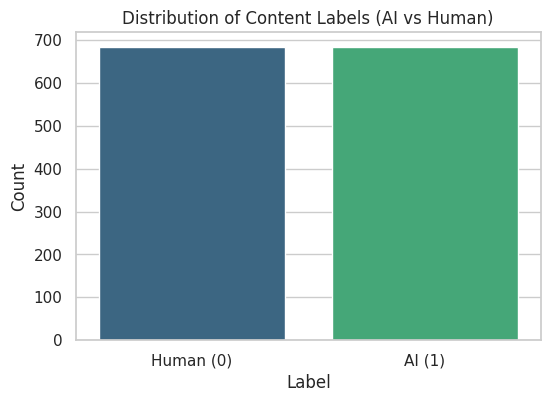


Label counts:
 label
0    684
1    683
Name: count, dtype: int64


In [ ]:
h1("Label Distribution")

# นับจำนวนแต่ละ label
label_counts = df['label'].value_counts()

# วาดกราฟ distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Content Labels (AI vs Human)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Human (0)', 'AI (1)']) # ให้ถือว่าค่า 0 = Human และ 1 = AI
plt.show()

print("\nLabel counts:\n", label_counts)

**Label**:

*   `0`: เนื้อหาที่เขียนโดยมนุษย์
*   `1`: เนื้อหาที่สร้างโดย AI

**สรุปผลจากกราฟ:**

*   **ข้อมูลมีความสมดุล (Balanced Dataset):** จำนวนเนื้อหาที่เขียนโดยมนุษย์ (684 แถว) และเนื้อหาที่สร้างโดย AI (683 แถว) มีจำนวนใกล้เคียงกันมาก ซึ่งถือว่าเป็นชุดข้อมูลที่มีความสมดุล (balanced dataset)
*   **ความสำคัญต่อการสร้างแบบจำลอง:** ชุดข้อมูลที่สมดุลเป็นสิ่งที่ดีสำหรับการสร้างแบบจำลองการจำแนกประเภท (classification model) เพราะแบบจำลองจะไม่เอนเอียง (biased) ไปทางป้ายกำกับ (class) ใด class หนึ่งเป็นพิเศษ ทำให้แบบจำลองมีประสิทธิภาพในการทำนายทั้งสอง class ได้ดีพอๆ กัน โดยไม่ต้องใช้เทคนิคพิเศษในการจัดการกับความไม่สมดุลของข้อมูล (imbalanced data)


**2. สำรวจการกระจายตัวของค่าในคอลัมน์ต่างๆ โดยแยกตามป้ายกำกับ (label)**

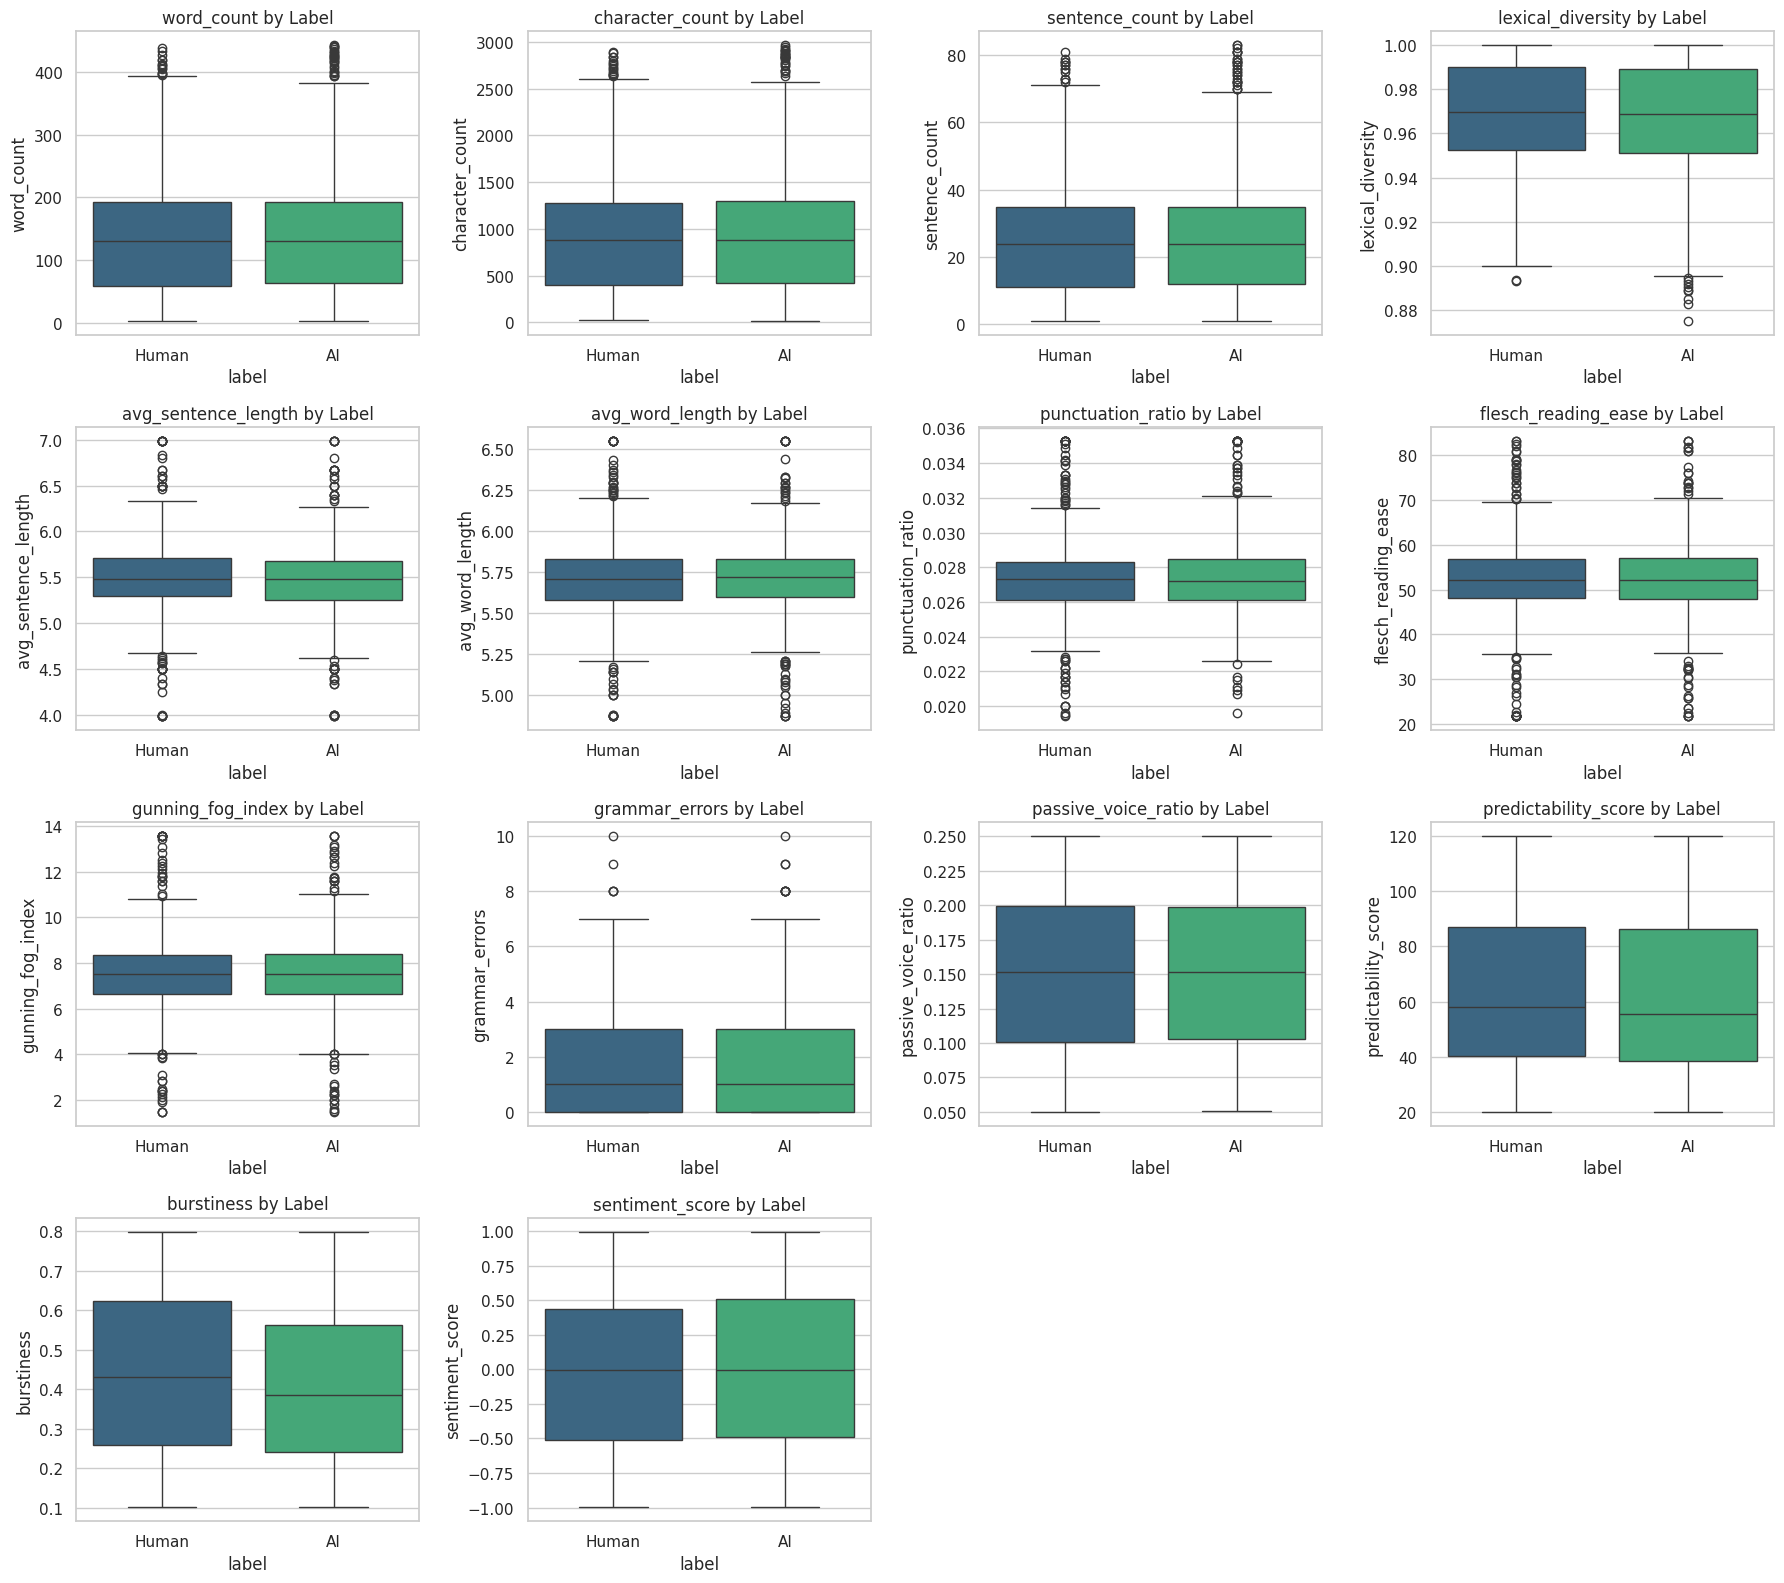

In [ ]:
# เลือกเฉพาะฟีเจอร์ที่เป็นตัวเลข โดยไม่รวมคอลัมน์ label
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# ตรวจสอบว่า label ไม่ถูกเลือก
if 'label' in numerical_features:
    numerical_features.remove('label')

n_features = len(numerical_features)
n_cols = 4 # กำหนดจำนวนคอลัมน์ของ subplot
n_rows = (n_features + n_cols - 1) // n_cols # คำนวณจำนวนแถวที่ต้องการสำหรับ subplot

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten() # แปลง axes จาก 2D เป็น 1D เพื่อให้ iterate ง่าย

for i, col in enumerate(numerical_features):
    # วาดกราฟ boxplot สำหรับแต่ละคอลัมน์ โดยแยกตามค่า label
    sns.boxplot(data=df, x='label', y=col, hue='label', ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} by Label')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Human', 'AI'])
    axes[i].legend([],[], frameon=False) # ลบ legend ออกจากแต่ละ subplot เพื่อไม่ให้กราฟรกเกินไป

# ปิด subplot ที่เหลือเมื่อจำนวนฟีเจอร์ไม่พอเติมเต็มทุกช่อง
for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.tight_layout() # ปรับ layout ไม่ให้ title/label ซ้อนกัน
plt.show()

**สรุปผลจากกราฟ:**

1. **Word / Character / Sentence Counts**
    *  ทั้งสองกลุ่มมีความยาวใกล้เคียงกัน  AI ไม่ได้เขียนข้อความสั้นหรือยาวกว่ามนุษย์อย่างมีนัยสำคัญ

2. **Avg Sentence Length / Avg Word Length**

    *  ความยาวประโยคและความยาวคำเฉลี่ยใกล้กันมาก แสดงให้เห็นถึงการสร้างประโยคของ AI ค่อนข้างคล้ายมนุษย์

3. **Lexical Diversity**

    *  ความหลากหลายของคำมีความคล้ายกัน ทำให้เห็นว่า AI สามารถใช้คำได้หลากหลายเหมือนมนุษย์มากขึ้น

4. **Punctuation Ratio**

    *  การใช้เครื่องหมายวรรคตอนแทบไม่ต่างกัน AI มีการใช้เครื่องหมายครบถ้วนคล้ายมนุษย์

5. **Flesch Reading Ease**

    *  ค่าความอ่านง่ายของมนุษย์ และ AI ใกล้เคียงกันมาก

6. **Gunning Fog Index**

    *  ระดับความซับซ้อนของภาษามีความใกล้เคียงกันทั้งมนุษย์และ AI

7. **Grammar Errors**

    * มนุษย์และ AI มีจำนวนข้อผิดพลาดทางไวยากรณ์ไม่ต่างกัน


8. **Passive Voice Ratio**

    *  ทั้งมนุษย์และ AI ใช้ passive voice ในระดับคล้ายกัน

9. **Predictability Score**

    * Predictability Score มีช่วงค่าใกล้เคียงกันระหว่างมนุษย์และ AI ในส่วนของค่ากลาง AI ต่ำกว่ามนุษย์เล็กน้อย สื่อถึง AI เขียนประโยคที่คาดเดาได้ง่ายกว่ามนุษย์

10. **Burstiness**

    * ค่าของมนุษย์สูงกว่า AI อย่างเห็นได้ชัดที่สุดเมื่อเทียบกับฟีเจอร์อื่นๆ แสดงว่ามนุษย์มีความยาวประโยคที่ผันผวนมากกว่า ขณะที่ AI มีลักษณะของประโยคที่สม่ำเสมอและเป็นแบบแผน

11. **Sentiment Score**

    * ค่าของมนุษย์และ AI มีค่ากลางใกล้เคียงกัน แต่มนุษย์มีช่วงการกระจายของอารมณ์ที่กว้างกว่า สะท้อนถึงความหลากหลายด้านอารมณ์ในข้อความมากกว่า AI

สรุป ข้อความที่มนุษย์และ AI เขียนมีลักษณะทางภาษาคล้ายกันแทบทุกด้าน ทั้งความยาวประโยค ความยาวคำ ความหลากหลายของคำ การใช้วรรคตอน ความอ่านง่าย ความซับซ้อนของภาษา รวมถึงข้อผิดพลาดทางไวยากรณ์ ทำให้แยกความแตกต่างได้ยาก ยกเว้นบางฟีเจอร์ เช่น Burstiness ที่มนุษย์มีความผันผวนของประโยคมากกว่า ขณะที่ AI มีรูปแบบการเขียนที่สม่ำเสมอและเป็นแบบแผนมากกว่า โดยรวมแล้วความแตกต่างมีเพียงเล็กน้อยและไม่เด่นชัดนัก

**3.การกระจายตัวของป้ายกำกับ (label) ตามประเภทเนื้อหา**

In [ ]:
df['content_type'].unique ()

array(['academic_paper', 'essay', 'creative_writing', 'news_article',
       'blog_post', 'article', 'social_media', 'product_review'],
      dtype=object)

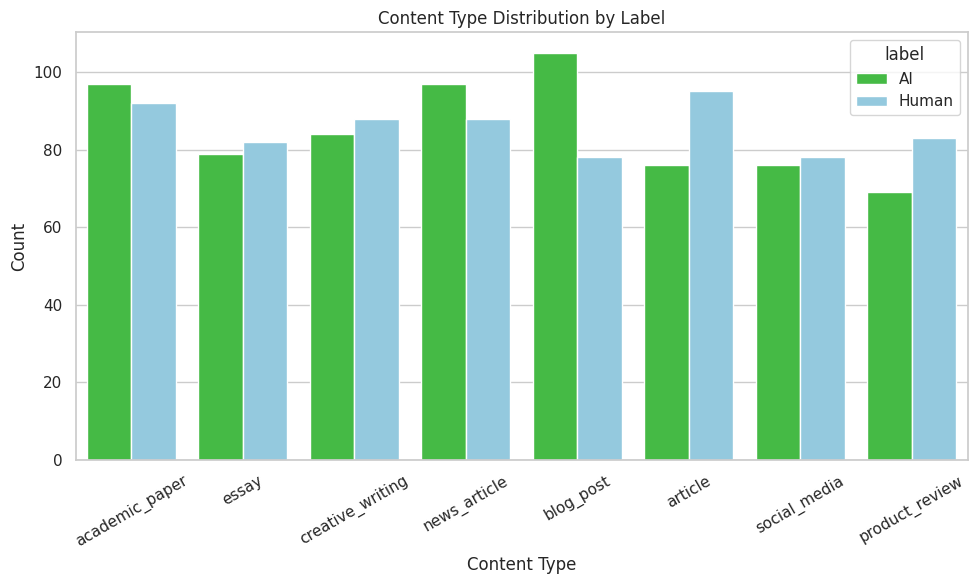


Label counts by Content Type:
 label              AI  Human
content_type                
academic_paper     97     92
article            76     95
blog_post         105     78
creative_writing   84     88
essay              79     82
news_article       97     88
product_review     69     83
social_media       76     78


In [ ]:
# ตรวจสอบว่า label เป็นตัวเลขหรือไม่
if df['label'].dtype != 'O':
    df['label'] = df['label'].map({0: 'Human', 1: 'AI'})

custom_palette = {'Human': 'skyblue', 'AI': 'limegreen'}

# สร้างกราฟแท่งของตัวแปร content_type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='content_type', hue='label', palette=custom_palette)
plt.title("Content Type Distribution by Label")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# นับจำนวนแต่ละ label ภายในแต่ละ content_type
content_type_counts = df.groupby('content_type')['label'].value_counts().unstack().fillna(0)
print("\nLabel counts by Content Type:\n", content_type_counts)

**สรุปผลจากกราฟ:**

1. **academic paper**
    *  AI เขียนมากกว่าเล็กน้อย (97 vs 92) แสดงว่า AI ถูกใช้ในงานวิชาการมากขึ้น

2. **essay**
    *  มนุษย์เขียนมากกว่าเล็กน้อย (82 vs 79) งานเรียงความยังอิงมนุษย์มากกว่า

3. **creative writing**
    *  มนุษย์เขียนมากกว่าเล็กน้อย (88 vs 84) งานเขียนเชิงสร้างสรรค์มนุษย์ยังได้เปรียบมากกว่า
  
4. **news article**
    *  AI เขียนมากกว่า (97 vs 88) ข่าวเป็นหมวดหมู่ที่ AI ถูกใช้มากที่สุดหมวดหนึ่ง

5. **blog post**
    *  AI เขียนมากกว่าอย่างชัดเจน (105 vs 78) แสดงว่า AI ถูกใช้ผลิตคอนเทนต์เพื่อเว็บบล็อกจำนวนมาก

6. **article**
    *  มนุษย์เขียนมากกว่าอย่างชัดเจน (95 vs 76) บทความทั่วไปยังเป็นงานที่มนุษย์ทำมากกว่า

7. **social media**
    *  มนุษย์มากกว่าเล็กน้อย (78 vs 76) โพสต์บนโซเชียลมนุษย์ยังมีบทบาทเด่นกว่า

8. **product review**
    *  มนุษย์มากกว่า (83 vs 69) รีวิวสินค้ายังเป็นงานที่มนุษย์ทำเป็นส่วนใหญ่

สรุป งานด้านวิชาการและข่าวมีแนวโน้มที่ AI จะเขียนมากกว่า โดยเฉพาะบล็อกโพสต์ที่ AI เขียนมากที่สุด ขณะที่งานที่ต้องใช้มุมมองเชิงมนุษย์ เช่น เรียงความ งานเขียนสร้างสรรค์ บทความทั่วไป รวมถึงรีวิวสินค้า ยังเป็นสิ่งที่มนุษย์มีบทบาทเด่นกว่าแม้ในยุคที่ AI ถูกใช้งานมากขึ้น นอกจากนี้คอนเทนต์โซเชียลมีเดียก็ยังคงเป็นพื้นที่ที่มนุษย์เขียนมากกว่าเล็กน้อย ภาพรวมทั้งหมดสะท้อนว่าแม้ AI จะมีศักยภาพสูงในงานเชิงโครงสร้างและข้อมูล แต่คอนเทนต์ที่ต้องอาศัยประสบการณ์ส่วนตัว ความเห็น หรือความรู้สึกเฉพาะบุคคลยังคงเป็นจุดแข็งของมนุษย์อยู่ในปัจจุบัน



**4.สำรวจความสัมพันธ์ระหว่างคุณสมบัติเชิงตัวเลข (Correlation Analysis)**

ดูว่าคุณสมบัติเชิงตัวเลขต่างๆ มีความสัมพันธ์กันมากน้อยแค่ไหน การที่คุณสมบัติสองตัวมีความสัมพันธ์กันสูงอาจบ่งชี้ว่าเราไม่จำเป็นต้องใช้ทั้งสองคุณสมบัตินั้นในแบบจำลอง หรือต้องระมัดระวังในการเลือกแบบจำลอง


Correlation Matrix of Numeric Features


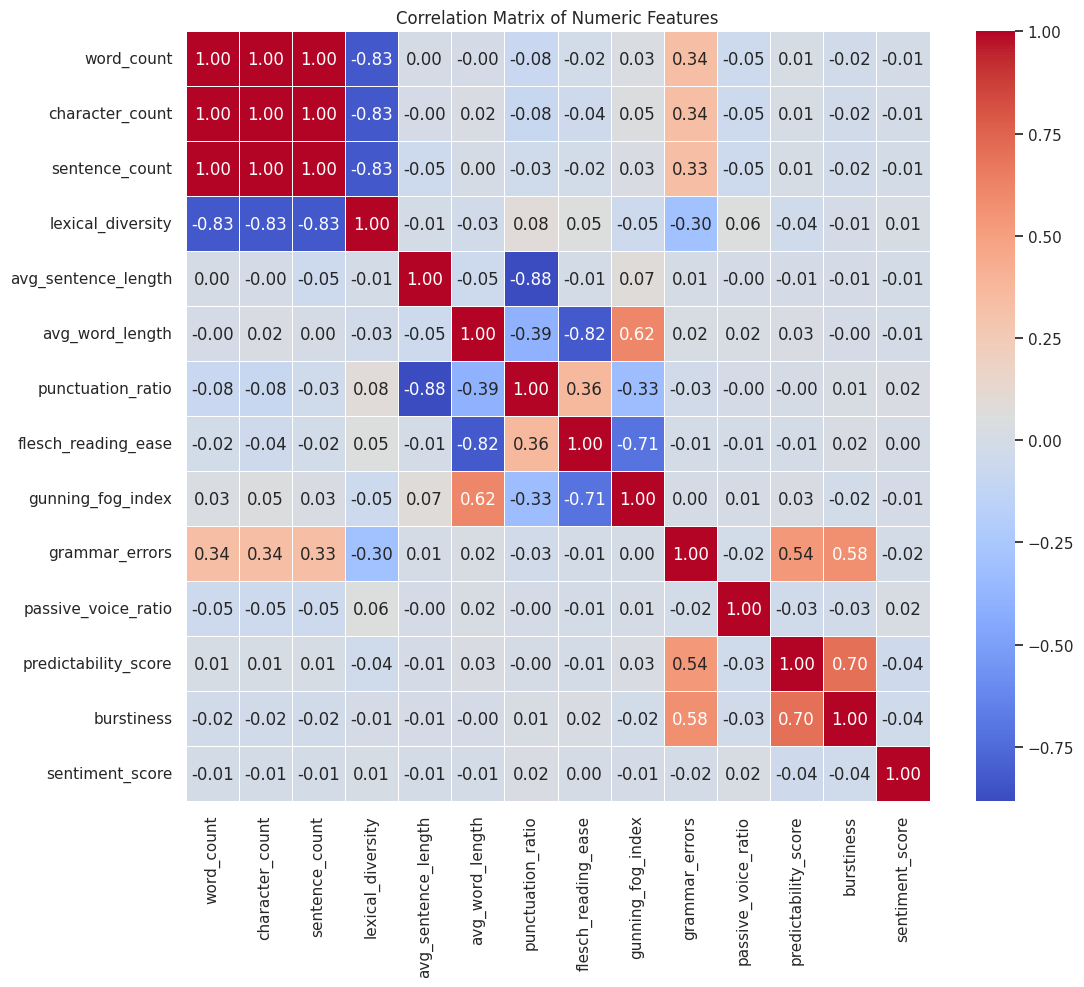

In [ ]:
h1("Correlation Matrix of Numeric Features")

# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขเพื่อนำไปวิเคราะห์ความสัมพันธ์
numeric_df = df.select_dtypes(include=np.number)

# คำนวณ correlation matrix
correlation_matrix = numeric_df.corr()

# วาดกราฟ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

**สรุปผลจากกราฟ:**

1.  **`word_count`, `character_count` และ `sentence_count` มีความสัมพันธ์กันสูงมาก:**
    *   คุณสมบัติทั้งสามนี้มีค่า Correlation ใกล้เคียง 1.00 ซึ่งแสดงถึงความสัมพันธ์เชิงบวกที่สูงมาก เนื่องจากคุณสมบัติเหล่านี้ล้วนเป็นการวัดความยาวของข้อความ
    *   **ข้อบ่งชี้:** การใช้คุณสมบัติทั้งสามนี้พร้อมกันในแบบจำลองอาจทำให้เกิดปัญหา Multicollinearity ได้ ควรพิจารณาเลือกใช้เพียงหนึ่งหรือสองคุณสมบัติจากกลุ่มนี้ เพื่อลดความซ้ำซ้อนของข้อมูล

2.  **`avg_word_length` และ `flesch_reading_ease` มีความสัมพันธ์เชิงลบสูง:**
    *   มีค่า Correlation เชิงลบที่ชัดเจน (ประมาณ -0.82)
    *   หมายความว่า ยิ่งความยาวเฉลี่ยของคำมากขึ้นเท่าใด คะแนนความง่ายในการอ่านก็มีแนวโน้มที่จะลดลงมากเท่านั้น
    *   **ข้อบ่งชี้:** เป็นความสัมพันธ์ที่สมเหตุสมผลตามหลักการของดัชนี Flesch Reading Ease ยิ่งคำยาว ยิ่งอ่านยาก

3.  **`lexical_diversity` มีความสัมพันธ์เชิงลบสูงกับคุณสมบัติความยาว:**
    *   มีค่า Correlation เชิงลบสูง (ประมาณ -0.83) กับ `word_count`, `character_count`, และ `sentence_count`
    *   หมายความว่า ยิ่งข้อความมีความยาวมากขึ้นเท่าใด ความหลากหลายของคำศัพท์ก็มีแนวโน้มที่จะลดลงมากเท่านั้น
    *   **ข้อบ่งชี้:** เป็นความสัมพันธ์ที่สมเหตุสมผลเช่นกัน ในข้อความที่ยาว มักจะมีการใช้คำซ้ำบ่อยขึ้น ทำให้ความหลากหลายของคำลดลง

4.  **`avg_sentence_length` และ `punctuation_ratio`  มีความสัมพันธ์เชิงลบสูง:**
    *   มีค่า Correlation เชิงลบสูง (ประมาณ -0.88)
    *   หมายความว่า ประโยคที่ยาวขึ้นมักมีสัดส่วนการใช้เครื่องหมายวรรคตอนน้อยลง
    *   **ข้อบ่งชี้:** ทั้งสองฟีเจอร์วัดลักษณะโครงสร้างประโยคแบบตรงข้ามกัน ควรหลีกเลี่ยงการใช้ร่วมกันในโมเดลเชิงเส้น

5.  **`avg_word_length` และ `gunning_fog_index` มีความสัมพันธ์เชิงบวกที่ดี:**
    *   มีค่า Correlation เชิงบวกที่ค่อนข้างดี (ประมาณ +0.62)
    *   หมายความว่า ยิ่งความยาวเฉลี่ยของคำมากขึ้นเท่าใด ดัชนีความยากในการอ่าน Gunning Fog Index ก็มีแนวโน้มที่จะสูงขึ้น(อ่านยากขึ้น) มากเท่านั้น
    *   **ข้อบ่งชี้:** เป็นความสัมพันธ์ที่สมเหตุสมผลตามหลักการของ Gunning Fog Index คำศัพท์ที่ซับซ้อน (คำยาว) ทำให้ข้อความอ่านยากขึ้น

6.  **`predictability_score` และ `burstiness` มีความสัมพันธ์เชิงบวกที่ดี:**
    *   มีค่า Correlation เชิงบวกค่อนข้างสูง (ประมาณ +0.70)
    *   หมายความว่า ข้อความที่คาดเดาได้ง่ายมักมีระดับความผกผันของจังหวะการเขียน (burstiness) สูงตามไปด้วย
คือแม้ข้อความจะสามารถคาดเดาได้ แต่ยังมีการสลับยาว-สั้นหรือรูปแบบจังหวะที่ไม่สม่ำเสมอ
    *   **ข้อบ่งชี้:** ฟีเจอร์ทั้งสองมีความคล้ายกันในด้านลักษณะของรูปแบบการเขียน
จึงอาจเกิดความซ้ำซ้อนในโมเดลได้


**5. สำรวจข้อมูลข้อความ (Text Data Exploration)**

แม้ว่าเราจะมีคุณสมบัติเชิงตัวเลขที่ได้จากข้อความแล้ว การดูเนื้อหาข้อความโดยตรงก็มีประโยชน์ ได้แก่:

*   **Word Cloud:** สร้าง Word Cloud เพื่อดูคำที่ปรากฏบ่อยๆ ในข้อความทั้งหมด หรือแยกตามกลุ่ม (AI vs Human)
*   **Common Words/N-grams:** นับคำที่ปรากฏบ่อยที่สุด หรือลำดับของคำ (N-grams) ในแต่ละกลุ่ม


**Word Cloud**

In [ ]:
!pip install wordcloud -q


Word Clouds by Label


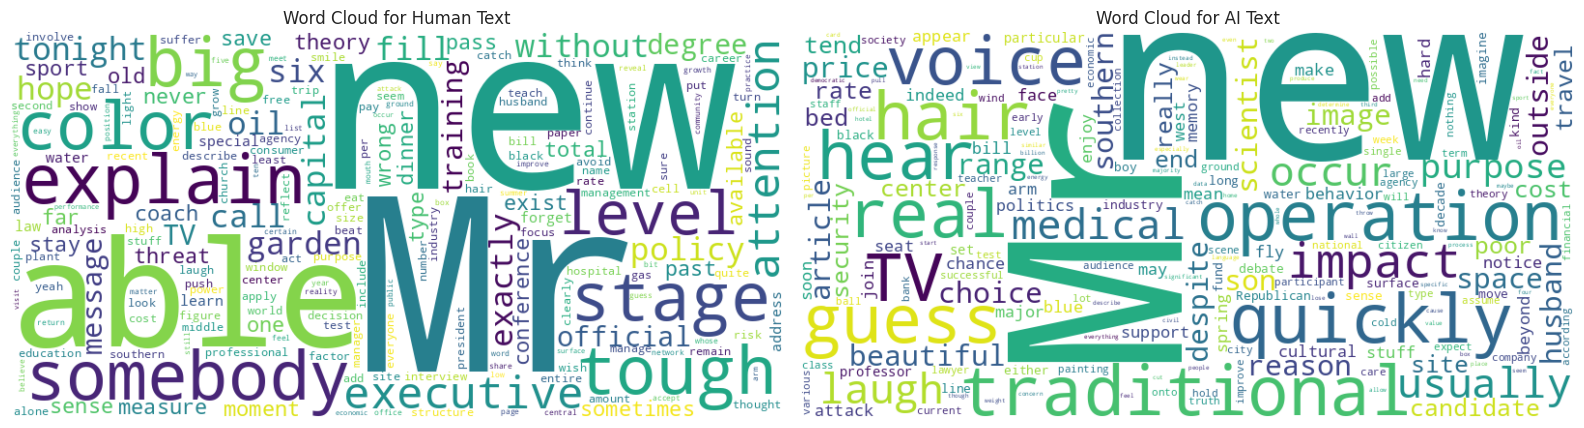

In [ ]:
from wordcloud import WordCloud

h1("Word Clouds by Label")

# แยกข้อความตามแต่ละ label
human_texts = df[df['label'] == 'Human']['text_content'].tolist()
ai_texts = df[df['label'] == 'AI']['text_content'].tolist()

# สร้าง Word Cloud สำหรับข้อความของมนุษย์
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
if human_texts:
    human_combined_text = ' '.join(human_texts)
    wordcloud_human = WordCloud(width=800, height=400, background_color='white').generate(human_combined_text)
    plt.imshow(wordcloud_human, interpolation='bilinear')
    plt.title('Word Cloud for Human Text')
else:
    plt.text(0.5, 0.5, "No human text available", horizontalalignment='center', verticalalignment='center')
    plt.title('Word Cloud for Human Text (No Data)')
plt.axis('off')


# สร้าง Word Cloud สำหรับข้อความของม AI
plt.subplot(1, 2, 2)
if ai_texts:
    ai_combined_text = ' '.join(ai_texts)
    wordcloud_ai = WordCloud(width=800, height=400, background_color='white').generate(ai_combined_text)
    plt.imshow(wordcloud_ai, interpolation='bilinear')
    plt.title('Word Cloud for AI Text')
else:
    plt.text(0.5, 0.5, "No AI text available", horizontalalignment='center', verticalalignment='center')
    plt.title('Word Cloud for AI Text (No Data)')

plt.axis('off')

plt.tight_layout()
plt.show()

**Common Words/N-grams**

In [ ]:
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

stop_words = set(stopwords.words('english'))

def clean_and_tokenize(text):
    """Cleans text and tokenizes."""
    if not isinstance(text, str):
        text = "" if pd.isna(text) else str(text)
    cleaned_text = text.lower().translate(str.maketrans('', '', string.punctuation))
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    tokens = cleaned_text.split()
    filtered_tokens = [word for word in tokens if word not in stop_words and word] # Also remove empty strings if any
    return filtered_tokens

def get_ngrams(tokens, n=1):
    """Generates n-grams from a list of tokens."""
    return list(ngrams(tokens, n))

h1("Common Words and Bigrams by Label")

# แยกข้อความตาม label
human_texts = df[df['label'] == 'Human']['text_content'].tolist()
ai_texts = df[df['label'] == 'AI']['text_content'].tolist()


# วิเคราะห์ข้อความของมนุษย์
print("\nAnalyzing Human Text...")
human_tokens = []
for text in human_texts:
    human_tokens.extend(clean_and_tokenize(text))

human_word_counts = Counter(human_tokens)
human_bigrams = get_ngrams(human_tokens, n=2)
human_bigram_counts = Counter(human_bigrams)

print("\nMost Common Words in Human Text:")
print(human_word_counts.most_common(20))

print("\nMost Common Bigrams in Human Text:")
print(human_bigram_counts.most_common(20))


# วิเคราะห์ข้อความของ AI
print("\nAnalyzing AI Text...")
ai_tokens = []
for text in ai_texts:
    ai_tokens.extend(clean_and_tokenize(text))

ai_word_counts = Counter(ai_tokens)
ai_bigrams = get_ngrams(ai_tokens, n=2)
ai_bigram_counts = Counter(ai_bigrams)

print("\nMost Common Words in AI Text:")
print(ai_word_counts.most_common(20))

print("\nMost Common Bigrams in AI Text:")
print(ai_bigram_counts.most_common(20))


Common Words and Bigrams by Label

Analyzing Human Text...

Most Common Words in Human Text:
[('able', 128), ('somebody', 127), ('explain', 127), ('big', 127), ('tough', 124), ('stage', 124), ('color', 124), ('level', 123), ('executive', 122), ('attention', 121), ('tonight', 121), ('exactly', 121), ('hope', 121), ('fill', 120), ('oil', 120), ('without', 120), ('six', 120), ('call', 119), ('policy', 119), ('garden', 119)]

Most Common Bigrams in Human Text:
[(('line', 'tonight'), 4), (('performance', 'message'), 4), (('seat', 'significant'), 4), (('policy', 'per'), 3), (('vote', 'help'), 3), (('military', 'attention'), 3), (('get', 'draw'), 3), (('practice', 'day'), 3), (('image', 'return'), 3), (('know', 'box'), 3), (('board', 'station'), 3), (('everything', 'result'), 3), (('land', 'certain'), 3), (('kind', 'high'), 3), (('analysis', 'yeah'), 3), (('share', 'national'), 3), (('free', 'fly'), 3), (('budget', 'cause'), 3), (('save', 'enter'), 3), (('war', 'tend'), 3)]

Analyzing AI Tex


Top 20 Most Common Words by Label (Bar Chart)


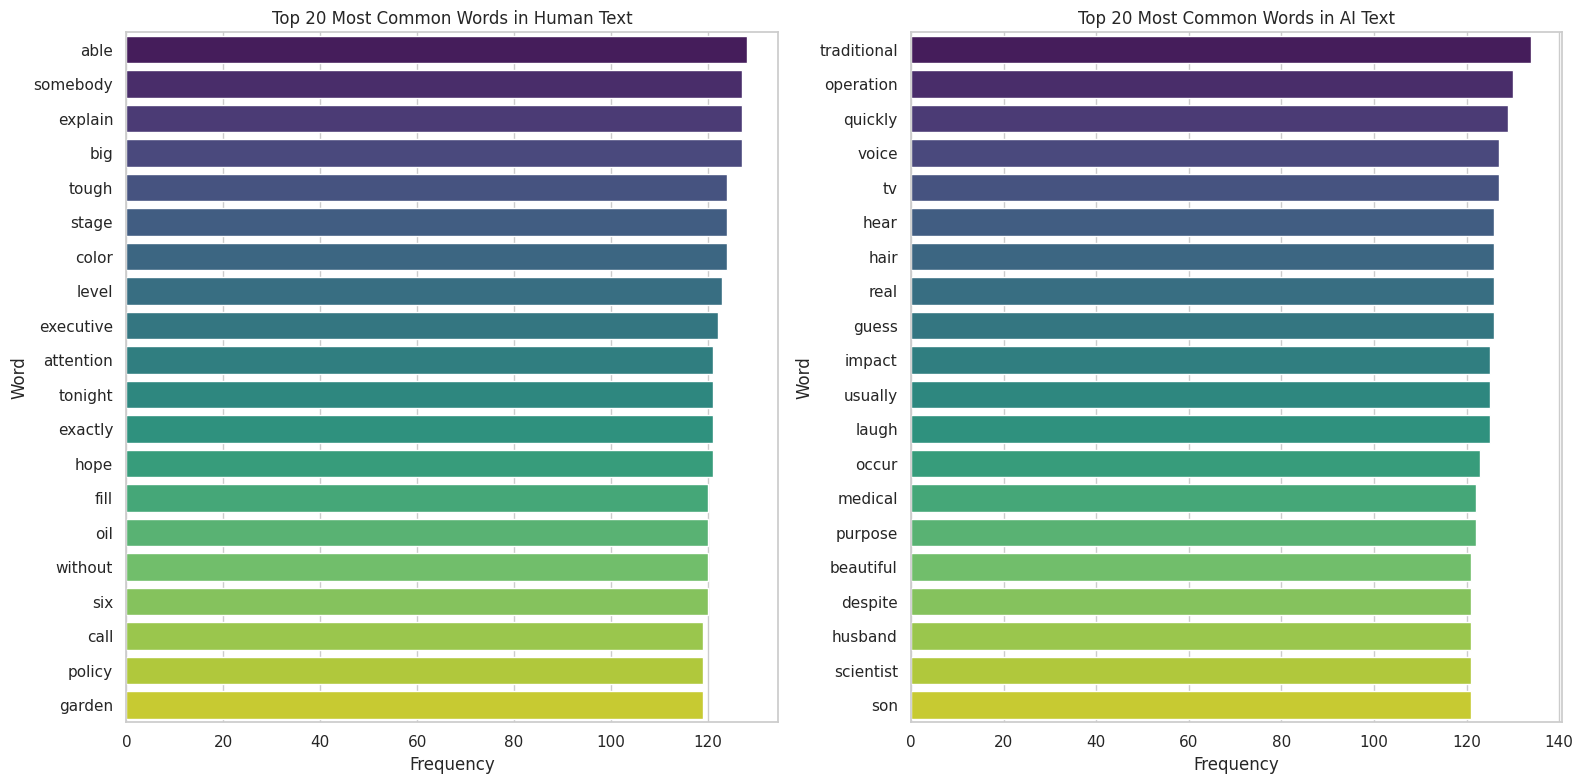


Top 20 Most Common Bigrams by Label (Bar Chart)


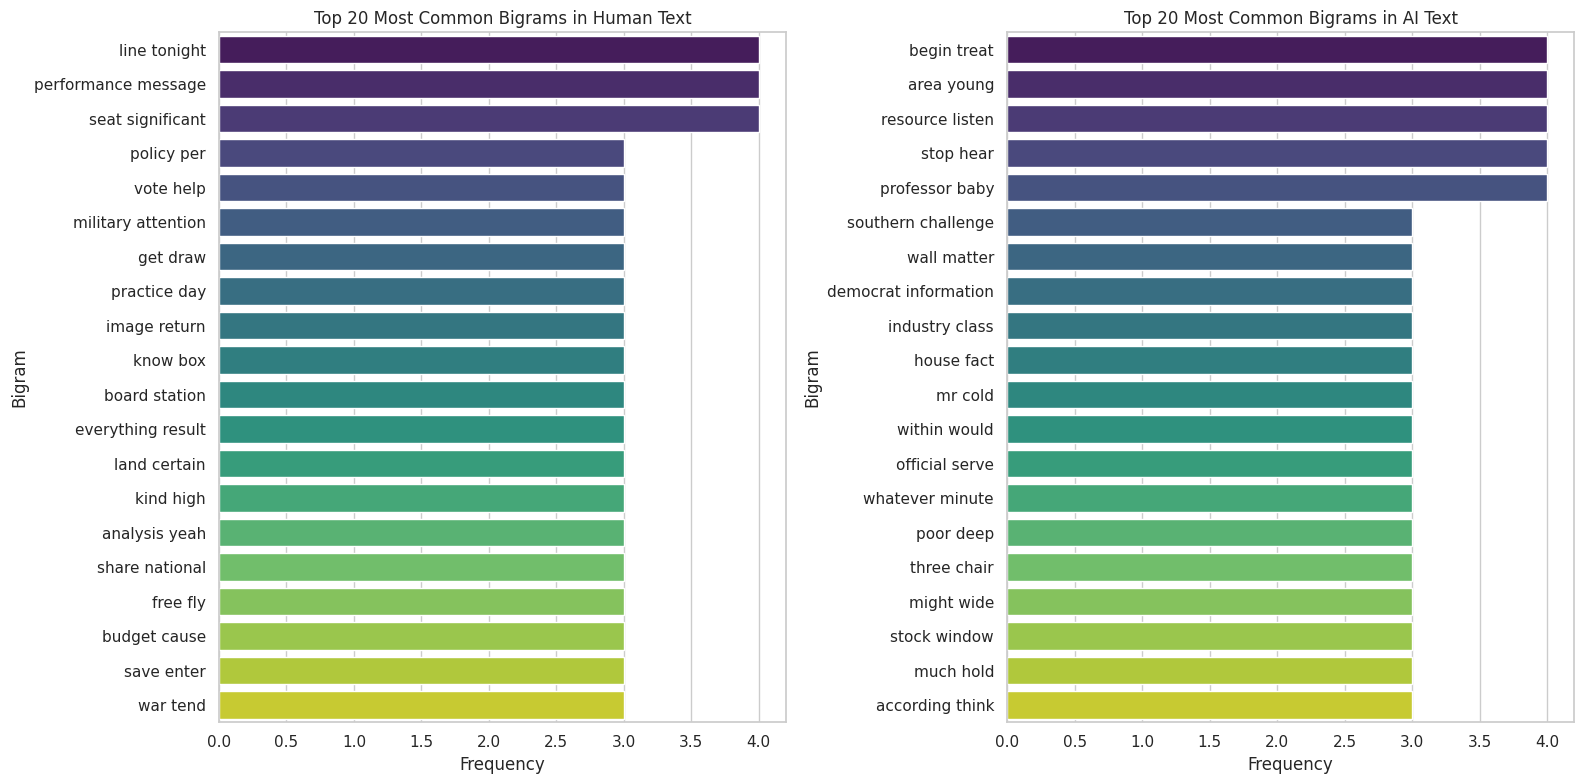

In [ ]:
h1("Top 20 Most Common Words by Label (Bar Chart)")

# เตรียมข้อมูลสำหรับทำกราฟ (เลือกเฉพาะ 20 อันดับแรก)
human_top_words = pd.DataFrame(human_word_counts.most_common(20), columns=['word', 'count'])
ai_top_words = pd.DataFrame(ai_word_counts.most_common(20), columns=['word', 'count'])

# สร้าง subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# วาดกราฟสำหรับข้อความของมนุษย์
sns.barplot(x='count', y='word', data=human_top_words, ax=axes[0], palette='viridis')
axes[0].set_title('Top 20 Most Common Words in Human Text')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Word')

# วาดกราฟสำหรับข้อความของ AI
sns.barplot(x='count', y='word', data=ai_top_words, ax=axes[1], palette='viridis')
axes[1].set_title('Top 20 Most Common Words in AI Text')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')

plt.tight_layout()
plt.show()


h1("Top 20 Most Common Bigrams by Label (Bar Chart)")

# เตรียมข้อมูลสำหรับทำกราฟ (เลือกเฉพาะ 20 bigrams แรก)
# แปลง bigram ที่อยู่ในรูป tuple ให้เป็น string เพื่อให้แสดงผลบนกราฟได้ง่ายขึ้น
human_top_bigrams = pd.DataFrame([(' '.join(bg), count) for bg, count in human_bigram_counts.most_common(20)], columns=['bigram', 'count'])
ai_top_bigrams = pd.DataFrame([(' '.join(bg), count) for bg, count in ai_bigram_counts.most_common(20)], columns=['bigram', 'count'])


# สร้าง subplots สำหรับ bigrams
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# วาดกราฟ bigrams ของมนุษย์
sns.barplot(x='count', y='bigram', data=human_top_bigrams, ax=axes[0], palette='viridis')
axes[0].set_title('Top 20 Most Common Bigrams in Human Text')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Bigram')

# วาดกราฟ bigrams ของ AI
sns.barplot(x='count', y='bigram', data=ai_top_bigrams, ax=axes[1], palette='viridis')
axes[1].set_title('Top 20 Most Common Bigrams in AI Text')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Bigram')

plt.tight_layout()
plt.show()

**สรุปผลจากกราฟ:**

*   **คำที่พบบ่อยที่สุด:** คำที่พบบ่อย 20 อันดับแรกของข้อความ Human และ AI นั้น แตกต่างกันอย่างชัดเจน คำที่พบบ่อยในกลุ่ม Human มักเป็นคำพื้นฐานทั่วไป หรือคำที่อาจปรากฏในบริบทการสนทนาหรือการเขียนที่ไม่เป็นทางการนัก เช่น able, somebody, explain, big, tough ในขณะที่คำที่พบบ่อยในกลุ่ม AI ดูเหมือนจะเป็นคำที่อาจปรากฏในบริบทที่เป็นทางการมากขึ้น หรือเกี่ยวข้องกับหัวข้อเฉพาะ เช่น traditional, operation, quickly, voice, impact, medical
*   **Bigrams ที่พบบ่อยที่สุด:** Bigrams ที่พบในกลุ่ม Human มักเป็นวลีที่เกิดจากการเขียนหรือการเล่าเรื่อง เช่น line tonight, performance message, seat significant, vote help, military attention, practice day ซึ่งมีความเป็นภาษาพูดสูงกว่า ในฝั่ง AI มีรูปแบบที่ คล้ายภาษาทางการมากกว่า เช่น begin treat, resource listen, democrat information, industry class, official serve ซึ่งสะท้อนสไตล์การเขียนของ AI ที่มักสร้างวลีที่ดูเหมือนมาจากบทความหรือรายงาน

**ข้อสังเกต:**

1.  **ความแตกต่างของคำศัพท์:** การที่คำศัพท์ที่พบบ่อยที่สุดในสองกลุ่มแตกต่างกันอย่างมาก เป็นตัวบ่งชี้สำคัญว่าลักษณะการใช้คำระหว่างข้อความ Human และ AI นั้นไม่เหมือนกัน AI อาจใช้คำศัพท์ที่มีความเฉพาะเจาะจงหรือเป็นไปตามรูปแบบที่เรียนรู้มาจากชุดข้อมูลฝึก ในขณะที่ Human มีความหลากหลายในการเลือกใช้คำมากกว่า
2.  **ความแตกต่างของวลี/โครงสร้างประโยคเบื้องต้น:** Bigrams ที่แตกต่างกันบ่งชี้ว่าไม่เพียงแต่คำศัพท์เดี่ยวๆ เท่านั้นที่แตกต่างกัน แต่รูปแบบการเรียงคำติดกัน ซึ่งเป็นส่วนหนึ่งของโครงสร้างประโยคก็มีความแตกต่างกันด้วย AI อาจมีแนวโน้มที่จะใช้สำนวนหรือวลีสำเร็จรูปบางอย่างซ้ำๆ บ่อยกว่า Human
3.  **ความถี่ที่ค่อนข้างต่ำของ Bigrams ที่พบบ่อยที่สุด:** สังเกตว่าจำนวนครั้งที่ปรากฏของ Bigrams ที่พบบ่อยที่สุดนั้นค่อนข้างต่ำ อาจบ่งชี้ได้ว่าชุดข้อมูลมีความหลากหลายของ Bigrams สูง หรือไม่มี Bigrams เด่นๆที่ปรากฏซ้ำบ่อยมากนักในภาพรวม
4.  **ศักยภาพในการเป็นคุณสมบัติ (Features):** ทั้งคำศัพท์เดี่ยวๆ และ Bigrams ที่แตกต่างกันนี้มีศักยภาพสูงที่จะถูกนำไปใช้เป็นคุณสมบัติ (features) ในการสร้างแบบจำลองการจำแนกประเภท (Classification Model) โดยเฉพาะการใช้เทคนิค Text Vectorization เช่น TF-IDF ซึ่งจะแปลงข้อมูลข้อความให้เป็นตัวเลขโดยอิงจากความถี่ของคำและ N-grams

โดยรวมแล้ว การวิเคราะห์คำและ N-grams ที่พบบ่อยนี้ช่วยยืนยันว่ามีรูปแบบภาษาที่แตกต่างกันอย่างมีนัยสำคัญระหว่างเนื้อหาที่สร้างโดย AI และเนื้อหาที่เขียนโดยมนุษย์ในชุดข้อมูลนี้ ซึ่งเป็นข้อมูลสำคัญสำหรับการพัฒนาแบบจำลอง

#Part 4 : Feature Engineering & Selection


จากการทำ EDA พบว่าฟีเจอร์บางตัวยังไม่สามารถสะท้อนความแตกต่างของรูปแบบการเขียนระหว่างข้อความของมนุษย์และ AI ได้อย่างชัดเจน จึงจำเป็นต้องทำ Feature Engineering เพื่อสร้างฟีเจอร์ที่มีความหมายมากขึ้น เช่น การสร้าง Advanced Text Features ที่ช่วยจับโครงสร้างภาษา ความซับซ้อน และสไตล์การเขียนที่ซ่อนอยู่ ซึ่งทำให้โมเดลสามารถเรียนรู้ลักษณะเฉพาะของแต่ละกลุ่มได้อย่างแม่นยำยิ่งขึ้น

## Feature Engineering

### Advanced Text Features

สกัดฟีเจอร์ทางภาษาเชิงลึกจากข้อความ โดยแปลงข้อความเป็นตัวเลขที่ใช้บอกลักษณะการเขียน เช่น โทนอารมณ์ ความยาวประโยค การใช้คำซ้ำ การใช้ตัวพิมพ์ใหญ่ การใช้ punctuation ฯลฯ เพื่อช่วยให้โมเดลแยกความแตกต่างระหว่างข้อความที่มนุษย์เขียนกับที่ AI เขียนได้แม่นยำขึ้น


**การทำงานของโค้ด**:

1. **ฟังก์ชัน `extract_advanced_features(text)`**
- รับข้อความทีละแถว แล้วคำนวณฟีเจอร์เชิงภาษาศาสตร์ เช่น
  - `sentiment_polarity`, `sentiment_subjectivity` จาก `TextBlob`
  - จำนวนประโยค (`num_sentences`)
  - ความยาวคำเฉลี่ย (`avg_word_length`)
  - สัดส่วนคำไม่ซ้ำ (`unique_word_ratio`)
  - สัดส่วน stopwords (`stopword_ratio`)
  - สัดส่วนตัวพิมพ์ใหญ่, ตัวเลข, ตัวอักษรพิเศษ
  - ความยาวประโยคเฉลี่ย (`avg_sentence_length`)
  - สัดส่วนคำยาว (`long_word_ratio`)
  - จำนวน `?`, `!`, อัตราส่วน `,` และ `;`
  - `word_diversity` วัดความหลากหลายของคำ

ถ้าข้อความว่างหรือ `NaN` จะคืนค่าฟีเจอร์ทุกตัวเป็น 0 เพื่อป้องกัน error

2. **ดึงฟีเจอร์จากทุกแถว**
- `nltk.download('punkt_tab')` ดาวน์โหลด resource ที่จำเป็นสำหรับการตัดประโยค
- ใช้ `.apply(extract_advanced_features)` กับคอลัมน์ `text_content`
- แปลงผลที่ได้เป็น DataFrame ชื่อ `text_features_df`
- แสดงจำนวนฟีเจอร์ที่สร้างได้ และดูตัวอย่างด้วย `head()`

In [ ]:
df_features = df.copy()

def extract_advanced_features(text):
    """Extract comprehensive linguistic features"""
    if pd.isna(text) or text == '':
        return {
            'sentiment_polarity': 0,
            'sentiment_subjectivity': 0,
            'num_sentences': 0,
            'avg_word_length': 0,
            'unique_word_ratio': 0,
            'stopword_ratio': 0,
            'uppercase_ratio': 0,
            'digit_ratio': 0,
            'special_char_ratio': 0,
            'avg_sentence_length': 0,
            'long_word_ratio': 0,
            'question_count': 0,
            'exclamation_count': 0,
            'comma_ratio': 0,
            'semicolon_ratio': 0,
            'word_diversity': 0
        }

    # วิเคราะห์ข้อความโดยใช้ TextBlob
    blob = TextBlob(str(text))

    # สถิติพื้นฐาน
    words = text.split()
    num_words = len(words)
    unique_words = len(set(words))

    # วิเคราะห์ Stopwords
    stop_words = set(stopwords.words('english'))
    stopword_count = sum(1 for word in words if word.lower() in stop_words)

    # วิเคราะห์ตัวอักษร
    num_uppercase = sum(1 for c in text if c.isupper())
    num_digits = sum(1 for c in text if c.isdigit())
    num_special = sum(1 for c in text if not c.isalnum() and not c.isspace())

    # วิเคราะห์ประโยค
    sentences = sent_tokenize(text)
    num_sentences = len(sentences)

    # วิเคราะห์ความยาวคำ
    word_lengths = [len(word) for word in words]
    long_words = sum(1 for length in word_lengths if length > 6)

    # วิเคราะห์เครื่องหมายวรรคตอน (Punctuation)
    comma_count = text.count(',')
    semicolon_count = text.count(';')

    return {
        'sentiment_polarity': blob.sentiment.polarity,
        'sentiment_subjectivity': blob.sentiment.subjectivity,
        'num_sentences': num_sentences,
        'avg_word_length': np.mean(word_lengths) if word_lengths else 0,
        'unique_word_ratio': unique_words / num_words if num_words > 0 else 0,
        'stopword_ratio': stopword_count / num_words if num_words > 0 else 0,
        'uppercase_ratio': num_uppercase / len(text) if len(text) > 0 else 0,
        'digit_ratio': num_digits / len(text) if len(text) > 0 else 0,
        'special_char_ratio': num_special / len(text) if len(text) > 0 else 0,
        'avg_sentence_length': num_words / num_sentences if num_sentences > 0 else 0,
        'long_word_ratio': long_words / num_words if num_words > 0 else 0,
        'question_count': text.count('?'),
        'exclamation_count': text.count('!'),
        'comma_ratio': comma_count / num_words if num_words > 0 else 0,
        'semicolon_ratio': semicolon_count / num_words if num_words > 0 else 0,
        'word_diversity': unique_words / np.sqrt(num_words) if num_words > 0 else 0
    }

# ดึง features
print("Extracting advanced text features...")
nltk.download('punkt_tab') # ดาวน์โหลด resource ที่หายไป
text_features = df_features['text_content'].apply(extract_advanced_features)
text_features_df = pd.DataFrame(text_features.tolist())

print(f"Advanced features extracted: {text_features_df.shape[1]} features")
print(text_features_df.head())

Extracting advanced text features...


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Advanced features extracted: 16 features
   sentiment_polarity  sentiment_subjectivity  num_sentences  avg_word_length  \
0            0.128860                0.400194             54         5.694444   
1            0.061689                0.343355             44         5.798419   
2            0.070141                0.439260             75         5.785714   
3            0.012469                0.381643             34         5.688776   
4            0.164394                0.402453             28         5.975000   

   unique_word_ratio  stopword_ratio  uppercase_ratio  digit_ratio  \
0           0.951389        0.090278         0.029061          0.0   
1           0.972332        0.067194         0.027341          0.0   
2           0.907143        0.097619         0.029835          0.0   
3           0.959184        0.071429         0.026718          0.0   
4           0.968750        0.043750         0.026009          0.0   

   special_char_ratio  avg_sentence_length  long_wo

**ผลลัพธ์ที่ได้:**

หลังจากใช้ฟังก์ชัน `extract_advanced_features` ระบบได้สร้างชุด ฟีเจอร์เชิงภาษาจำนวน 16 ฟีเจอร์จากคอลัมน์ text_content โดยฟีเจอร์เหล่านี้ถูกแปลงให้อยู่ในรูปแบบตัวเลขทั้งหมด เช่น sentiment polarity, จำนวนประโยค, ความยาวคำเฉลี่ย, อัตราส่วนคำซ้ำ, การใช้ตัวอักษรพิเศษ, จำนวนคำยาว, และการใช้เครื่องหมายวรรคตอน เป็นต้น
โดยผลลัพธ์ทั้งหมดถูกจัดเก็บใน DataFrame ชื่อ
text_features_df
ซึ่งมีโครงสร้างเป็นตารางฟีเจอร์เชิงตัวเลขพร้อมใช้งานสำหรับโมเดล Machine Learning



**16 ฟีเจอร์ที่ถูกสร้างขึ้นมาเพิ่ม มีดังนี้:**


1.   sentiment_polarity - ค่าความเป็นลบ/บวกของข้อความ
2.   sentiment_subjectivity - ความเป็นความเห็น (subjective) หรือข้อเท็จจริง (objective)
3.  num_sentences - จำนวนประโยคทั้งหมดในข้อความ
4.  avg_sentence_length - จำนวนคำเฉลี่ยต่อประโยค
5.  avg_word_length - ความยาวเฉลี่ยของคำ
6.  unique_word_ratio - สัดส่วนของคำที่ไม่ซ้ำ
7.  stopword_ratio - สัดส่วนของคำที่เป็น stopwords เช่น the, an, to
8.  long_word_ratio - สัดส่วนของคำยาว
9.  word_diversity - ค่าความหลากหลายของคำ
10.  uppercase_ratio - สัดส่วนตัวอักษรพิมพ์ใหญ่จากจำนวนตัวทั้งหมด
11.  digit_ratio - สัดส่วนตัวเลขในข้อความ
12.  special_char_ratio - สัดส่วนตัวอักษรพิเศษ เช่น !, @, #, &, %
13.  question_count - จำนวนเครื่องหมายคำถาม
14.  exclamation_count - จำนวนเครื่องหมายอัศเจรีย์
15.  comma_ratio - จำนวน comma ต่อจำนวนคำ
16.  semicolon_ratio - จำนวน semicolon ต่อจำนวนคำ


หลังจากสร้าง Advanced Text Features เพื่อเพิ่มมิติของข้อมูลและช่วยให้โมเดลสามารถเรียนรู้โครงสร้างภาษาได้ละเอียดขึ้น ขั้นตอนถัดมาคือการเตรียมข้อมูล (Comprehensive Preprocessing) เพื่อรวมฟีเจอร์ทั้งหมดให้อยู่ในรูปแบบที่เหมาะสมสำหรับการนำไปฝึกโมเดล Machine Learning

### Comprehensive Preprocessing

**เตรียมฟีเจอร์เชิงตัวเลขก่อนเข้าโมเดล**

**1. แยกตัวแปรเป้าหมาย (Target)**
- `y_full = df_features['label']`  
- เก็บ label ไว้ต่างหากสำหรับใช้เทรน/ประเมินโมเดล

**2. ดึงฟีเจอร์เชิงตัวเลขดิบ**
- `X_numeric_raw = df_features.drop(['label', 'text_content', 'content_type'], axis=1)`  
-  เอาคอลัมน์ที่ไม่ใช่ label, ข้อความดิบ และประเภท content ออกไป เหลือแต่คอลัมน์เชิงตัวเลข

**3. จัดการ missing values**
- หาเฉพาะคอลัมน์ประเภทตัวเลข (`int64`, `float64`)
- เติมค่า missing ด้วยค่า median ของแต่ละคอลัมน์  
-  กันปัญหา NaN ก่อนเข้าโมเดล

**4. One-hot encoding ให้ `content_type`**
- `pd.get_dummies(..., prefix='content', drop_first=True)`  
-  แปลงประเภท content ให้เป็นคอลัมน์ตัวเลข (dummy variables) แล้ว drop ตัวแรกเพื่อกัน multicollinearity

**5. รวมฟีเจอร์ทั้งหมด**
- `X_numeric_combined = pd.concat([X_numeric_raw, text_features_df, content_type_encoded], axis=1)`  
-  รวม
    - ฟีเจอร์ตัวเลขดิบที่ทำความสะอาดแล้ว  
    - ฟีเจอร์ภาษา (จาก `text_features_df`)  
   - ฟีเจอร์ one-hot ของ `content_type`


In [ ]:
#comprehensive preprocessing
# แยกตัวแปรเป้าหมาย
y_full = df_features['label']

# ดึงฟีเจอร์เชิงตัวเลข
X_numeric_raw = df_features.drop(['label', 'text_content', 'content_type'], axis=1)

# จัดการ missing values
numeric_cols = X_numeric_raw.select_dtypes(include=['int64', 'float64']).columns
X_numeric_raw[numeric_cols] = X_numeric_raw[numeric_cols].fillna(X_numeric_raw[numeric_cols].median())

# One-hot encoding ให้ content_type
content_type_encoded = pd.get_dummies(df_features['content_type'], prefix='content', drop_first=True)

# รวมฟีเจอร์ทั้งหมด
X_numeric_combined = pd.concat([X_numeric_raw, text_features_df, content_type_encoded], axis=1)

print(f"Numeric + Engineered features: {X_numeric_combined.shape[1]}")

Numeric + Engineered features: 37


**ผลลัพธ์ที่ได้:**

หลังจากการรวมฟีเจอร์ทั้งหมด ตอนนี้เรามี 37 ฟีเจอร์ โดยแบ่งเป็นฟีเจอร์เดิมจำนวน 18 ฟีเจอร์, ฟีเจอร์ใหม่ที่สร้างจากการทำ Advanced Text Feature จำนวน 16 ฟีเจอร์, และฟีเจอร์จาก One-hot Encoding ของตัวแปร `content_type`อีก 3 ฟีเจอร์

หลังจากรวมฟีเจอร์ทั้งหมดแล้ว ขั้นตอนถัดมาคือการเพิ่มฟีเจอร์ที่สะท้อนเนื้อหาและรูปแบบการใช้คำโดยตรง จึงได้สร้างฟีเจอร์จาก TF-IDF และ Character n-grams ซึ่งช่วยให้โมเดลมองเห็นความสำคัญของคำ การเรียงคำ และลักษณะการเขียนเชิงสไตล์ที่แตกต่างระหว่างมนุษย์และ AI ช่วยทำให้ข้อมูลมีความสมบูรณ์ทั้งในด้านความหมายและด้านรูปแบบภาษา ก่อนนำไปใช้ฝึกโมเดลต่อไป

### TF-IDF & Character N-grams

 **แปลงข้อความเป็นฟีเจอร์ตัวเลข**

แปลงคอลัมน์ `text_content` เป็นฟีเจอร์ตัวเลข 2 แบบ เพื่อใช้กับโมเดล ML


 **1) TF-IDF (ระดับคำ / word n-grams)**

- ใช้ `TfidfVectorizer` กับคำและ n-grams ขนาด 1–3 (unigram, bigram, trigram)
- ตัดคำที่เจอน้อยเกินไป (`min_df=3`) และคำที่เจอบ่อยเกินไป (`max_df=0.85`)
- แปลงเป็นตัวพิมพ์เล็ก, ตัด `stop_words` ภาษาอังกฤษ
- จำกัดจำนวนฟีเจอร์ที่ `max_features=2000`
- ผลลัพธ์: เมทริกซ์ `X_tfidf` (แถว = ข้อความ, คอลัมน์ = ฟีเจอร์ TF-IDF)


**2) Character n-grams (สไตล์การเขียน / stylometry)**

- ใช้ `TfidfVectorizer` แบบ `analyzer='char'`
- ใช้ character n-grams ขนาด 2–4 ตัวอักษร
- จำกัด `max_features=500`
- ผลลัพธ์: เมทริกซ์ `X_char` ที่สะท้อน pattern ตัวอักษรและสไตล์การเขียน



In [ ]:
# TF-IDF WITH IMPROVED PARAMETERS

print("\nExtracting TF-IDF features...")

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.85,
    strip_accents='unicode',
    lowercase=True,
    sublinear_tf=True,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(df_features['text_content']).toarray()
print(f"TF-IDF features: {X_tfidf.shape[1]}")

# Character n-grams สำหรับงานวิเคราะห์สไตล์การเขียน (Stylometry)
char_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 4),
    max_features=500
)
X_char = char_vectorizer.fit_transform(df_features['text_content']).toarray()
print(f"Character n-gram features: {X_char.shape[1]}")


Extracting TF-IDF features...
TF-IDF features: 2000
Character n-gram features: 500


**ผลลัพธ์ที่ได้:**

ได้ฟีเจอร์จากการทำ TF-IDF ของคอลัมน์ `text_content` จำนวน 2,000 ฟีเจอร์ และ
ได้ฟีเจอร์แบบ character n-grams เพิ่มอีก 500 ฟีเจอร์ เมื่อรวมกันแล้ว จะได้ทั้งหมด 2,500 ฟีเจอร์ ที่พร้อมนำไปรวมกับฟีเจอร์เชิงตัวเลขและฟีเจอร์ทางภาษาที่สร้างไว้ก่อนหน้า เพื่อใช้ฝึกโมเดล Machine Learning ต่อไป

หลังจากได้ฟีเจอร์จากการทำ TF-IDF และ Character n-grams รวมถึงฟีเจอร์เชิงตัวเลขและฟีเจอร์ภาษาที่ได้จากการทำ Feature Engineering ก่อนหน้า จำนวนฟีเจอร์ทั้งหมดมีขนาดใหญ่และหลากหลายมาก ดังนั้นจึงจำเป็นต้องทำ Feature Selection เพื่อคัดเฉพาะฟีเจอร์ที่มีความสำคัญต่อการจำแนกข้อความ



## Feature Selection

**รวมทุกฟีเจอร์และเลือกเฉพาะฟีเจอร์ที่สำคัญก่อนส่งเข้าโมเดล**

**1. รวมฟีเจอร์ทั้งหมด**
   - ใช้ `np.hstack` รวม:
     - `X_numeric_combined`  → ฟีเจอร์เชิงตัวเลข + engineered features
     - `X_tfidf`             → ฟีเจอร์ TF-IDF จากข้อความ
     - `X_char`              → ฟีเจอร์ character n-grams  
   - `print` ดูจำนวนฟีเจอร์ทั้งหมดก่อนคัดเลือก

**2. เลือกฟีเจอร์ด้วย chi-square (chi2)**
   - ใช้ `SelectKBest(chi2, k=min(800, จำนวนฟีเจอร์ทั้งหมด))`
   - เลือกฟีเจอร์ที่สัมพันธ์กับ label มากที่สุด **สูงสุด 800 ฟีเจอร์**
   - ใช้ `np.abs(X_all_features)` เพราะ chi2 ต้องการค่าที่ไม่ติดลบ
   - ได้เมทริกซ์ใหม่ `X_selected` ที่มีเฉพาะฟีเจอร์ที่ถูกคัดมาแล้ว


In [ ]:
#Feature Selection

print("\nApplying feature selection...")

# รวมฟีเจอร์ทั้งหมด
X_all_features = np.hstack([
    X_numeric_combined.values,
    X_tfidf,
    X_char
])

print(f"Total features before selection: {X_all_features.shape[1]}")

# เลือกฟีเจอร์ที่ดีที่สุดโดยใช้ chi2
selector = SelectKBest(chi2, k=min(800, X_all_features.shape[1]))
X_selected = selector.fit_transform(np.abs(X_all_features), y_full)

print(f"Features after selection: {X_selected.shape[1]}")


Applying feature selection...
Total features before selection: 2537
Features after selection: 800


**ผลลัพธ์ที่ได้:**

ก่อนการคัดเลือก ฟีเจอร์ทั้งหมดที่ได้จากฟีเจอร์เชิงตัวเลข, Advanced Text Features, TF-IDF และ Character n-grams มีจำนวนรวม 2,537 ฟีเจอร์ หลังจากใช้เทคนิค SelectKBest ร่วมกับสถิติ chi-square ได้เลือกเฉพาะฟีเจอร์ที่มีความสำคัญไว้ทั้งหมด 800 ฟีเจอร์ ซึ่งช่วยให้โมเดลเรียนรู้ได้ง่ายขึ้น เร็วขึ้น และลดความเสี่ยงของการเกิด overfit ในการฝึกโมเดลได้

#Part 5 :  Modeling

หลังจากการทำ Feature Engineering และ Feature Selection แล้ว จนได้ชุดฟีเจอร์ที่เหมาะสม ขั้นตอนต่อมาคือการสร้างโมเดล โดยเริ่มจากการเตรียมข้อมูลให้พร้อมใช้งานผ่านการแบ่งข้อมูลออกเป็นชุดฝึก/ชุดทดสอบ และปรับสเกลฟีเจอร์

## Train–Test Split & Scaling

**เตรียมชุดข้อมูลสำหรับเทรนโมเดล**

**1. Scaling ฟีเจอร์**
   - ใช้ `StandardScaler()` แปลงฟีเจอร์ใน `X_selected` ให้อยู่ในสเกลใกล้เคียงกัน  
   -  ช่วยให้โมเดลที่อ่อนไหวกับสเกล (เช่น SVM, Logistic Regression, MLP) ทำงานได้ดีขึ้น

**2. แบ่ง Train / Test**
   - ใช้ `train_test_split(...)` แบ่งข้อมูลเป็น  
     - `X_train, y_train` 80% สำหรับเทรน  
     - `X_test, y_test` 20% สำหรับทดสอบ
   - ใช้ `stratify=y_full` เพื่อให้สัดส่วนคลาสใน train/test ใกล้เคียงกับทั้ง dataset


In [ ]:
# TRAIN-TEST SPLIT & SCALING

# ปรับสเกลฟีเจอร์
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Class proportions:\n{pd.Series(y_train).value_counts(normalize=True)}")


Train shape: (1093, 800), Test shape: (274, 800)
Train class distribution:
label
0    547
1    546
Name: count, dtype: int64
Class proportions:
label
0    0.500457
1    0.499543
Name: proportion, dtype: float64


หลังจากปรับสเกลฟีเจอร์ด้วย StandardScaler แล้วได้ทำการแบ่งข้อมูลออกเป็นชุดเทรน 80% และชุดทดสอบ 20% โดยใช้ stratify เพื่อรักษาสัดส่วนคลาสให้สมดุล

**ได้ผลลัพธ์ดังนี้:**

- ชุด Train มี 1,093 แถว และ 800 ฟีเจอร์  
- ชุด Test มี 274 แถว และ 800 ฟีเจอร์

- คลาส 0 ใน train = 547 ตัวอย่าง (~50.05%)
- คลาส 1 ใน train = 546 ตัวอย่าง (~49.95%)

สรุปได้ว่าข้อมูลทั้งฝั่ง train มีสัดส่วนคลาสสมดุลเกือบ 50:50 ซึ่งเหมาะกับการฝึกโมเดล

หลังจากแบ่งข้อมูลเป็นชุดฝึกและชุดทดสอบเรียบร้อยแล้ว ขั้นตอนถัดไปคือการจัดการสัดส่วนของคลาสในข้อมูล เพื่อให้โมเดลเรียนรู้ได้อย่างสมดุลมากขึ้น แม้ข้อมูลจะมีสัดส่วนคลาสใกล้เคียงกัน แต่เพื่อให้โมเดลไม่เอนเอียงไปทางคลาสใดคลาสหนึ่ง จึงมีการใช้เทคนิค Class Weights แทนการทำ oversampling หรือ undersampling โดยให้ระบบคำนวณ weight ของแต่ละคลาสตามจำนวนตัวอย่างและส่งค่าเหล่านี้เข้าโมเดลในขั้นตอนการเทรน

## Class Weights

**จัดการปัญหา Class Imbalance**

เตรียม class weights แทนการทำ oversampling/undersampling:

- ใช้ `compute_class_weight('balanced', ...)` คำนวณ weight ให้แต่ละคลาสอัตโนมัติ ตามสัดส่วนจำนวนตัวอย่าง
- แปลงผลลัพธ์เป็น `class_weight_dict` เพื่อส่งเข้าโมเดล (เช่น Logistic Regression, SVM, MLP ฯลฯ)
- ไม่ได้สร้างตัวอย่างใหม่ใด ๆ:
  - `X_train_balanced = X_train`
  - `y_train_balanced = y_train`


In [ ]:
# จัดการปัญหา Class Imbalance ด้วย class weights
print("USING CLASS WEIGHTS FOR IMBALANCE")
# คำนวณ class weights
class_weights_array = compute_class_weight('balanced',
                                           classes=np.unique(y_train),
                                           y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights_array)}
print(f"Class weights: {class_weight_dict}")

#  ใช้ข้อมูลจริง (original data) โดยไม่จำเป็นต้องทำการสุ่มข้อมูลสังเคราะห์ (synthetic sampling)
X_train_balanced = X_train
y_train_balanced = y_train

USING CLASS WEIGHTS FOR IMBALANCE
Class weights: {0: np.float64(0.9990859232175503), 1: np.float64(1.000915750915751)}


**ผลลัพธ์ที่ได้:**

- ค่า weight ที่คำนวณได้คือ  
  - คลาส 0 → น้ำหนัก ≈ 0.9991  
  - คลาส 1 → น้ำหนัก ≈ 1.0009  

คลาสทั้งสองแทบจะสมดุลกันอยู่แล้ว น้ำหนักจึงใกล้เคียง 1 ทั้งคู่ ทำให้โมเดลไม่ได้ปรับเอนเอียงไปทางคลาสใดคลาสหนึ่งมากนัก

หลังจากเตรียมข้อมูลเรียบร้อย ทั้งการปรับฟีเจอร์ แบ่งชุดข้อมูล และกำหนด class weights เพื่อจัดการปัญหาความไม่สมดุลของคลาสแล้ว ขั้นตอนถัดไปคือการนำข้อมูลที่ผ่านการเตรียมทั้งหมดไปใช้ในการเทรนโมเดล โดยทดลองโมเดลหลากหลายประเภท เพื่อเปรียบเทียบประสิทธิภาพและระบุว่ารูปแบบใดเหมาะสมที่สุดสำหรับงานจำแนกข้อความมนุษย์และ AI ในโปรเจคนี้

## Model Training

 **เทรนโมเดลหลักชุดใหญ่ (6 โมเดล)**

เทรนโมเดลหลายแบบบนฟีเจอร์ที่เตรียมไว้แล้ว (`X_train_balanced`, `y_train_balanced`) โดยปรับพารามิเตอร์ให้เหมาะขึ้น และใส่ class weight ให้รองรับ class imbalance

### โมเดลที่เทรนในเซลล์นี้

1. **Logistic Regression**
   - `max_iter=1000`, `C=1.0`, `solver='lbfgs'`
   - ใช้ `class_weight='balanced'` ปรับน้ำหนักคลาสอัตโนมัติ

2. **Random Forest**
   - `n_estimators=300`, `max_depth=20`, `max_features='sqrt'`
   - ใช้ `class_weight='balanced'` และรันหลาย core (`n_jobs=-1`)

3. **SVM (RBF Kernel)**
   - `kernel='rbf'`, `C=1.0`, `gamma='scale'`
   - เปิด `probability=True` เพื่อให้ predict probability ได้
   - ใช้ `class_weight='balanced'`

4. **XGBoost**
   - `n_estimators=300`, `max_depth=7`, `learning_rate=0.05`, `subsample=0.8`, `colsample_bytree=0.8`
   - ใช้ `scale_pos_weight` ตามอัตราส่วนคลาส 0:1 เพื่อชดเชย class imbalance
   - ใช้ `eval_metric='logloss'`

5. **Gradient Boosting**
   - `n_estimators=200`, `learning_rate=0.1`, `max_depth=5`, `subsample=0.8`

6. **Neural Network (ANN) – Keras Functional API**
   - โครงสร้าง:
     - Input → Dense(256, relu) → BatchNorm → Dropout(0.5)  
     - Dense(128, relu) → BatchNorm → Dropout(0.4)  
     - Dense(64, relu) → Dropout(0.3)  
     - Output: Dense(1, sigmoid) สำหรับ binary classification
   - Compile ด้วย `optimizer='adam'`, `loss='binary_crossentropy'`, metric = `accuracy`
   - ใช้ `EarlyStopping` ดู `val_loss`, `patience=15`, `restore_best_weights=True`
   - เทรนด้วย:
     - `epochs=100`, `batch_size=16`
     - `validation_split=0.2`
     - `class_weight=class_weight_dict`

เตรียมโมเดลหลัก 6 ตัว ทั้งสาย classic ML + tree-based + deep learning เพื่อนำไปเปรียบเทียบ performance ในขั้นตอนถัดไป

In [ ]:
# MODEL TRAINING WITH OPTIMIZED PARAMETERS

print("\n" + "="*50)
print("TRAINING OPTIMIZED MODELS")
print("="*50)

# 1. Logistic Regression
print("\n[1/6] Training Logistic Regression...")
log_reg = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)
log_reg.fit(X_train_balanced, y_train_balanced)

# 2. Random Forest
print("\n[2/6] Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_balanced, y_train_balanced)

# 3. SVM
print("\n[3/6] Training SVM...")
svm = SVC(
    probability=True,
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train_balanced, y_train_balanced)

# 4. XGBoost
print("\n[4/6] Training XGBoost...")
scale_pos_weight = (y_train_balanced == 0).sum() / (y_train_balanced == 1).sum()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train_balanced, y_train_balanced)

# 5. Gradient Boosting
print("\n[5/6] Training Gradient Boosting...")
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train_balanced, y_train_balanced)

# 6. Improved ANN
print("\n[6/6] Training Neural Network...")

# สร้าง ANN ด้วย Functional API
inputs = Input(shape=(X_train_balanced.shape[1],))
x = Dense(256, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

ann = Model(inputs=inputs, outputs=outputs)
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = ann.fit(
    X_train_balanced, y_train_balanced,
    epochs=100,
    batch_size=16,
    class_weight=class_weight_dict,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"ANN training completed. Stopped at epoch: {len(history.history['loss'])}")



TRAINING OPTIMIZED MODELS

[1/6] Training Logistic Regression...

[2/6] Training Random Forest...

[3/6] Training SVM...

[4/6] Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:47:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



[5/6] Training Gradient Boosting...

[6/6] Training Neural Network...


**ผลลัพธ์ที่ได้:**

- โมเดลทั้ง 6 ตัว (Logistic Regression, Random Forest, SVM, XGBoost, Gradient Boosting, Neural Network) ฝึกครบเรียบร้อยแล้ว
- XGBoost ขึ้นแค่คำเตือนว่า parameter `use_label_encoder` ไม่ได้ใช้งาน (ไม่มีผลกับการฝึกจริง สามารถมองข้ามได้)
- Neural Network (ANN) ใช้ Early Stopping และหยุดฝึกที่ epoch ที่ 21 เพราะ `val_loss` ไม่ดีขึ้นต่อเนื่องแล้ว ซึ่งช่วยกัน overfitting


หลังจากฝึกโมเดล Machine Learning ทั้ง 6 ตัวเรียบร้อยแล้ว ขั้นตอนถัดไปเราจะทำการใช้โมเดลด้านภาษาอย่าง DistilBERT เพื่อวัดประสิทธิภาพของวิธีแบบ Transformer ในการจำแนกข้อความของมนุษย์และ AI

## Transformer Model (DistilBERT)

**DistilBERT** คือโมเดลภาษาแบบ Deep Learning
ที่ถูกสร้างจาก BERT แต่ทำให้เล็กลง และเร็วขึ้น แต่ยังเก่งใกล้เคียงของเดิม
อยู่ในโมเดลในตระกูล Transformer ซึ่งเป็นเทคโนโลยี NLP สมัยใหม่ที่สามารถเข้าใจความหมายของประโยค บริบทคำ และความสัมพันธ์ของคำได้อย่างลึกซึ้ง โดยไม่ต้องพึ่ง Feature Engineering


**Text Classification**

ใช้ DistilBERT มาทำงานจำแนกข้อความ (AI vs Human) แบบ end-to-end

**1. เตรียม device และชุดข้อความ**
- เช็กว่ามี GPU ไหม → ถ้ามีจะใช้ `cuda` ช่วยเร่งความเร็ว
- แบ่ง train/test ใหม่จาก `df_features` ด้วย `train_test_split` (stratify ตาม `y_full`)
- สร้าง:
  - `train_texts`, `train_labels`
  - `test_texts`, `test_labels`

 **2. โหลด tokenizer และเตรียม Dataset**
- ใช้โมเดล `"distilbert-base-uncased"`
- สร้างฟังก์ชัน `tokenize_batch(...)`:
  - padding แบบ `max_length`
  - truncation ความยาวสูงสุด `max_length=256`
- แปลงเป็น `Dataset` ของ HuggingFace:
  - `train_dataset`, `test_dataset`
- map tokenization แล้วตั้ง format เป็น PyTorch (`input_ids`, `attention_mask`, `label`)

**3. โหลดโมเดล DistilBERT สำหรับ classification**
- `AutoModelForSequenceClassification` กับ `num_labels=2`
- `problem_type="single_label_classification"`

**4. TrainingArguments + Callback**
- ตั้งค่า `TrainingArguments` เช่น:
  - `num_train_epochs=3`
  - `per_device_train_batch_size=8`
  - `weight_decay=0.01`
  - `logging_steps=50`
  - `eval_strategy="epoch"`, `save_strategy="epoch"`
  - `load_best_model_at_end=True`, `metric_for_best_model="accuracy"`
  - `dataloader_num_workers=0` (กันปัญหาค้างในบาง environment)
  - ปิดการส่ง log ออกภายนอกด้วย `report_to="none"`
- สร้าง `ETAProgressCallback` เพื่อ print ความคืบหน้าระหว่างเทรน (epoch, step, ETA แบบคร่าว ๆ)

**5. สร้าง Trainer และเทรนโมเดล**
- `Trainer(...)` รวม:
  - โมเดล, arguments, train/test dataset
  - ฟังก์ชัน `compute_metrics` (accuracy, precision, recall, f1)
  - callback แสดง progress
- รัน `trainer.train()` เพื่อเทรน DistilBERT

**6. ประเมินผลบน Test set**
- ใช้ `trainer.predict(test_dataset)` เพื่อได้ logits
- แปลงเป็น:
  - `transformer_pred_labels` (คลาสที่ทำนาย)
  - `transformer_pred_probs` (probability ของคลาส 1 ผ่าน softmax)
- คำนวณและแสดง **Transformer Test Accuracy** บน test set

In [ ]:
# 10. TRANSFORMER MODEL (BERT/DistilBERT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# เตรียมข้อมูลสำหรับโมเดล Transformer
train_indices = list(range(len(X_train_balanced)))
test_indices = list(range(len(X_test)))

# Reconstruct train/test split indices จากข้อมูลต้นฉบับอีกครั้ง
from sklearn.model_selection import train_test_split as tts
train_idx, test_idx = train_test_split(
    range(len(df_features)),
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

train_texts = df_features['text_content'].iloc[train_idx].tolist()
train_labels = y_full.iloc[train_idx].tolist()
test_texts = df_features['text_content'].iloc[test_idx].tolist()
test_labels = y_full.iloc[test_idx].tolist()

print(f"Train samples: {len(train_texts)}, Test samples: {len(test_texts)}")

# ใช้ DistilBERT
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize function
def tokenize_batch(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

# สร้างชุดข้อมูล
train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels})

train_dataset = train_dataset.map(tokenize_batch, batched=True)
test_dataset = test_dataset.map(tokenize_batch, batched=True)

# ตั้งค่า format สำหรับ PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# โหลดโมเดลที่ถูกเทรนไว้ล่วงหน้า
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    problem_type="single_label_classification"
)

# สร้าง callback แบบกำหนดเองเพื่อพิมพ์ความคืบหน้าของ epoch, batch และเวลาคงเหลือ (ETA)
from transformers import TrainerCallback
import time

class ETAProgressCallback(TrainerCallback):
    def on_train_begin(self, args, state, control, **kwargs):
        self.train_start_time = time.time()

    def on_epoch_begin(self, args, state, control, **kwargs):
        self.epoch_start_time = time.time()
        print(f"\n Starting Epoch {state.epoch:.0f}/{args.num_train_epochs}")

    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step % args.logging_steps == 0:
            elapsed = time.time() - self.train_start_time
            steps_done = state.global_step
            steps_total = args.num_train_epochs * state.max_steps // args.num_train_epochs
            eta = (elapsed / steps_done) * (steps_total - steps_done) if steps_done > 0 else 0
            print(f"    Step {state.global_step} completed (Epoch {int(state.epoch)}), ETA: {int(eta)} sec")

# พารามิเตอร์สำหรับการเทรน (FIXED: เพิ่ม dataloader_num_workers=0 เพื่อป้องกันอาการค้าง)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    dataloader_num_workers=0,  # ป้องกันไม่ให้ระบบค้างใน Kaggle
    report_to="none",  # ปิดการทำงานของระบบบันทึกภายนอก (Disable external logging)
)

# Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    prec = precision_score(labels, predictions, zero_division=0)
    rec = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

# สร้าง Trainer พร้อม callback สำหรับแสดง ETA
trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[ETAProgressCallback],
)

# เทรนโมเดล
print("\nTraining Transformer (this may take 5-10 minutes)...")
trainer.train()
print("Transformer training completed!")

# ดึงผลการทำนายจากโมเดล Transformer
transformer_predictions = trainer.predict(test_dataset)
transformer_pred_labels = np.argmax(transformer_predictions.predictions, axis=-1)
transformer_pred_probs = torch.nn.functional.softmax(
    torch.tensor(transformer_predictions.predictions), dim=-1
).numpy()[:, 1]

print(f"\nTransformer Test Accuracy: {accuracy_score(test_labels, transformer_pred_labels):.4f}")

Using device: cuda
Train samples: 1093, Test samples: 274


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training Transformer (this may take 5-10 minutes)...

 Starting Epoch 0/3


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.697900,0.693396,0.500000,0.500000,1.000000,0.666667
2,0.694100,0.694022,0.500000,0.500000,1.000000,0.666667
3,0.691500,0.692706,0.521898,0.542857,0.277372,0.367150


    Step 50 completed (Epoch 0), ETA: 65 sec
    Step 100 completed (Epoch 0), ETA: 53 sec

 Starting Epoch 1/3
    Step 150 completed (Epoch 1), ETA: 68 sec
    Step 200 completed (Epoch 1), ETA: 50 sec
    Step 250 completed (Epoch 1), ETA: 36 sec

 Starting Epoch 2/3
    Step 300 completed (Epoch 2), ETA: 25 sec
    Step 350 completed (Epoch 2), ETA: 13 sec
    Step 400 completed (Epoch 2), ETA: 2 sec
Transformer training completed!



Transformer Test Accuracy: 0.5219


**สรุปผลการฝึก Transformer (DistilBERT):**

โมเดล DistilBERT ถูกเทรนทั้งหมด 3 epochs โดยใช้ชุดข้อมูลข้อความที่เตรียมไว้ และประมวลผลบน GPU เพื่อเพิ่มความเร็ว ผลลัพธ์ที่ได้จากตารางการเทรนแสดงว่า training loss และ validation loss ลดลงอย่างช้า ๆ ในแต่ละ epoch แต่ค่า Accuracy, Precision, Recall และ F1 ยังคงใกล้เคียงกันตลอดช่วงการเทรน โดยไม่เกิดการพัฒนาที่ชัดเจน ซึ่งสะท้อนว่าโมเดลยังไม่สามารถแยกความแตกต่างระหว่างข้อความของมนุษย์กับ AI ได้ดีเท่าที่ควร

บนชุดทดสอบ โมเดลทำได้ Accuracy = 0.5219 หรือประมาณ 52% ซึ่งใกล้เคียงการทายแบบสุ่ม (50%) แสดงโมเดล DistilBERT ยังไม่สามารถจับความแตกต่างเฉพาะของข้อความทั้งสองกลุ่มได้มากนักในชุดข้อมูลนี้

หลังจากสร้างโมเดล Machine Learning แบบดั้งเดิมและโมเดล DistilBERT แล้ว ขั้นตอนต่อไปคือการปรับปรุงประสิทธิภาพของโมเดลฝั่ง Traditional ML ด้วยเทคนิคการรวมโมเดล (Ensemble) เพื่อใช้จุดแข็งของแต่ละโมเดลร่วมกัน โดยสร้าง Voting Classifier ที่รวมผลทำนายของโมเดลหลายตัวเข้าด้วยกันในรูปแบบ soft voting เพื่อเพิ่มความเสถียรและความแม่นยำของการจำแนกข้อความมนุษย์และ AI

## Ensemble Model (Traditional ML) – Voting Classifier

สร้างโมเดลรวม (Ensemble) จากโมเดล ML แบบดั้งเดิมหลายตัว โดยใช้ `VotingClassifier` แบบ soft voting:

- โมเดลที่นำมารวม:
  - `lr`  → Logistic Regression  
  - `rf`  → Random Forest  
  - `svm` → SVM  
  - `xgb` → XGBoost  
  - `gb`  → Gradient Boosting  

- ใช้ `voting='soft'` เพื่อเอา probability จากแต่ละโมเดลมาเฉลี่ย (ถ่วงน้ำหนัก)  
- กำหนดน้ำหนักโมเดล: `[1, 2, 1, 2, 1]`  
  และให้น้ำหนักเพิ่มกับ `Random Forest` และ `XGBoost`


In [ ]:
# ENSEMBLE MODEL (Traditional ML)

print("CREATING TRADITIONAL ML ENSEMBLE")

# Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rf),
        ('svm', svm),
        ('xgb', xgb),
        ('gb', gb)
    ],
    voting='soft',
    weights=[1, 2, 1, 2, 1]
)

voting_clf.fit(X_train_balanced, y_train_balanced)
print("Traditional ensemble trained successfully")

CREATING TRADITIONAL ML ENSEMBLE
Traditional ensemble trained successfully


หลังจากสร้าง Ensemble จากโมเดล ML แล้ว ขั้นตอนถัดไปคือการรวมผลทำนายของ Transformer (DistilBERT) และโมเดลดั้งเดิมเข้าด้วยกัน เพื่อสร้าง Hybrid Ensemble ที่ใช้จุดแข็งของทั้งสองฝั่งในการทำนายให้แม่นยำและเสถียรมากขึ้น

## Hybrid Ensemble

สร้างโมเดลลูกผสม (Hybrid Ensemble) โดยรวมผลจาก Transformer (DistilBERT) + โมเดล ML แบบดั้งเดิมเข้าด้วยกัน

**ขั้นตอน:**

**1. ดึง probability จากโมเดลดั้งเดิมทุกตัวบนชุด `X_test`**
   - `lr_probs`  จาก Logistic Regression  
   - `rf_probs`  จาก Random Forest  
   - `svm_probs` จาก SVM  
   - `xgb_probs` จาก XGBoost  
   - `gb_probs`  จาก Gradient Boosting  
   - `voting_probs` จาก Voting Classifier

**2. รวมกับ Transformer ด้วยการถ่วงน้ำหนัก**
   - ใช้ `transformer_pred_probs` ร่วมกับ prob ของโมเดลอื่น ๆ
   - กำหนดน้ำหนักประมาณ:
     - 40% → Transformer  
     - 15% → Random Forest  
     - 15% → XGBoost  
     - 10% → Gradient Boosting  
     - 10% → Voting Ensemble  
     - 10% → Logistic Regression  
   - รวมเป็น `hybrid_probs` (ค่า probability สุดท้าย)

**3. แปลงเป็นคลาสทำนาย**
   - ถ้า `hybrid_probs > 0.5` ให้เป็นคลาส 1, ไม่งั้นเป็นคลาส 0
   - คำนวณ Hybrid Ensemble Accuracy บน `y_test` และพิมพ์ผลออกมา


In [ ]:
# HYBRID ENSEMBLE (Transformer + Traditional ML)

print("CREATING HYBRID ENSEMBLE")

# ดึงผลการทำนายจากโมเดลแบบดั้งเดิมทั้งหมด (traditional models)
lr_probs = log_reg.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]
svm_probs = svm.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:, 1]
gb_probs = gb.predict_proba(X_test)[:, 1]
voting_probs = voting_clf.predict_proba(X_test)[:, 1]

# ค่าเฉลี่ยถ่วงน้ำหนัก: ให้โมเดล Transformer มีน้ำหนักมากกว่า
hybrid_probs = (
    0.4 * transformer_pred_probs +  # ให้น้ำหนัก 40% กับโมเดล Transformer
    0.15 * rf_probs +               # ให้น้ำหนัก 15% กับ Random Forest
    0.15 * xgb_probs +              # ให้น้ำหนัก 15% กับ XGBoost
    0.10 * gb_probs +               # ให้น้ำหนัก 15% กับ gradient boosting
    0.10 * voting_probs +           # ให้น้ำหนัก 15% กับ voting ensemble
    0.10 * lr_probs                 # ให้น้ำหนัก 15% กับ logistic regression
)

hybrid_predictions = (hybrid_probs > 0.5).astype(int)

print(f"Hybrid Ensemble Accuracy: {accuracy_score(y_test, hybrid_predictions):.4f}")
print("Hybrid model created successfully!")

CREATING HYBRID ENSEMBLE
Hybrid Ensemble Accuracy: 0.6350
Hybrid model created successfully!


**สรุปผล Hybrid Ensemble:**

โมเดล Hybrid Ensemble ซึ่งผสานผลทำนายจาก Transformer และโมเดล Machine Learning หลายตัว สามารถทำความแม่นยำบนชุดทดสอบได้ Accuracy = 0.6350

#Part 6 :  Model Evaluation

หลังจากสร้างโมเดลทุกประเภทเรียบร้อยแล้ว ทั้งโมเดล Machine Learning, โมเดลเชิงลึกแบบ Transformer และ Hybrid Ensemble ขั้นตอนนี้คือการสรุปผลและประเมินประสิทธิภาพของโมเดลทั้งหมด เพื่อให้เห็นภาพรวมของความสามารถในการจำแนกข้อความมนุษย์และ AI


**เปรียบเทียบโมเดลทั้งหมด**

**1. ฟังก์ชัน `evaluate_model(...)`**

รองรับทั้ง:
- โมเดลทั่วไป (sklearn)
- ANN (Keras)
- โมเดล Transformer / Hybrid (ใช้ผลทำนายที่เตรียมไว้)

ภายในฟังก์ชันจะคำนวณ:
- `Accuracy`
- `Precision`
- `Recall`
- `F1 Score`
- `Sensitivity` (Recall ของคลาสบวก)
- `Specificity` (Recall ของคลาสลบ)
- สร้าง `confusion_matrix` และดึง `tn, fp, fn, tp`

คืนค่า:
- list ของ metric ทั้ง 6 ตัว
- confusion matrix
- y_pred (ผลทำนายของโมเดล)

**2. รายชื่อโมเดลที่ประเมิน**

ใน `models_to_evaluate` ประเมินทั้งหมด 9 โมเดล:

- Logistic Regression  
- Random Forest  
- SVM  
- XGBoost  
- Gradient Boosting  
- ANN (Neural Network)  
- Traditional Ensemble (Voting Classifier)  
- Transformer (DistilBERT)  
- Hybrid Ensemble (Transformer + Traditional ML)

แต่ละตัวจะเรียก `evaluate_model(...)` ให้ตรงกับประเภทโมเดล แล้วเก็บผลไว้ใน:
- `results`              → metric ต่าง ๆ
- `confusion_matrices`   → confusion matrix ของแต่ละโมเดล
- `predictions`          → y_pred ของแต่ละโมเดล

พร้อม print metric หลัก (Accuracy, Precision, Recall, F1) ของแต่ละตัวบนหน้าจอ


In [ ]:
# MODEL EVALUATION (ALL MODELS)

def evaluate_model(model, X_test, y_test, is_ann=False, is_transformer=False, transformer_preds=None):
    """Comprehensive model evaluation"""
    if is_transformer:
        y_pred = transformer_preds
    elif is_ann:
        y_pred_prob = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_pred_prob > 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    return [acc, prec, rec, f1, sensitivity, specificity], cm, y_pred

# ประเมินผลโมเดลทั้งหมด
models_to_evaluate = {
    "Logistic Regression": (log_reg, False, False, None),
    "Random Forest": (rf, False, False, None),
    "SVM": (svm, False, False, None),
    "XGBoost": (xgb, False, False, None),
    "Gradient Boosting": (gb, False, False, None),
    "ANN": (ann, True, False, None),
    "Traditional Ensemble": (voting_clf, False, False, None),
    "Transformer (DistilBERT)": (None, False, True, transformer_pred_labels),
    "Hybrid Ensemble": (None, False, True, hybrid_predictions)
}

results = {}
confusion_matrices = {}
predictions = {}

print("\n" + "="*50)
print("EVALUATING ALL MODELS")
print("="*50)

for name, (model, is_ann, is_transformer, transformer_preds) in models_to_evaluate.items():
    if is_transformer:
        metrics, cm, y_pred = evaluate_model(None, X_test, y_test, False, True, transformer_preds)
    else:
        metrics, cm, y_pred = evaluate_model(model, X_test, y_test, is_ann, False, None)

    results[name] = metrics
    confusion_matrices[name] = cm
    predictions[name] = y_pred

    print(f"\n--- {name} ---")
    print(f"Accuracy: {metrics[0]:.4f}")
    print(f"Precision: {metrics[1]:.4f}")
    print(f"Recall: {metrics[2]:.4f}")
    print(f"F1 Score: {metrics[3]:.4f}")

results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1 Score", "Sensitivity", "Specificity"]
).T

print("\n" + "="*50)
print("FINAL MODEL PERFORMANCE COMPARISON")
print("="*50)
print(results_df)


EVALUATING ALL MODELS

--- Logistic Regression ---
Accuracy: 0.6496
Precision: 0.6454
Recall: 0.6642
F1 Score: 0.6547

--- Random Forest ---
Accuracy: 0.6277
Precision: 0.6241
Recall: 0.6423
F1 Score: 0.6331

--- SVM ---
Accuracy: 0.7372
Precision: 0.7241
Recall: 0.7664
F1 Score: 0.7447

--- XGBoost ---
Accuracy: 0.6022
Precision: 0.6014
Recall: 0.6058
F1 Score: 0.6036

--- Gradient Boosting ---
Accuracy: 0.5839
Precision: 0.5782
Recall: 0.6204
F1 Score: 0.5986

--- ANN ---
Accuracy: 0.6642
Precision: 0.6286
Recall: 0.8029
F1 Score: 0.7051

--- Traditional Ensemble ---
Accuracy: 0.6533
Precision: 0.6544
Recall: 0.6496
F1 Score: 0.6520

--- Transformer (DistilBERT) ---
Accuracy: 0.5219
Precision: 0.5429
Recall: 0.2774
F1 Score: 0.3671

--- Hybrid Ensemble ---
Accuracy: 0.6350
Precision: 0.6370
Recall: 0.6277
F1 Score: 0.6324

FINAL MODEL PERFORMANCE COMPARISON
                          Accuracy  Precision    Recall  F1 Score  \
Logistic Regression       0.649635   0.645390  0.664234  0

**สรุปผลโมเดลด้วยกราฟ**

**1. Confusion Matrix ของทุกโมเดล**

- สร้าง subplot หลายช่อง (เรียงเป็นแถว/คอลัมน์)
- วาด `confusion_matrix` ของแต่ละโมเดลด้วย `sns.heatmap`
  - แกน X = Predicted (AI / Human)  
  - แกน Y = Actual (AI / Human)
- ชื่อกราฟแต่ละช่องจะบอกชื่อโมเดล + ค่า Accuracy คร่าว ๆ
- ช่อง subplot ที่เกิน (ถ้ามี) จะถูกซ่อน

ซึ่งช่วยให้เห็นว่าแต่ละโมเดลพลาดตรงไหนบ้าง (false positive / false negative)



**2. กราฟ Bar เปรียบเทียบ Metric**

- ใช้ `results_df.plot(kind='bar')` วาดกราฟ bar:
  - แกน X = ชื่อโมเดล
  - แกน Y = ค่า metric (Accuracy, Precision, Recall, F1, Sensitivity, Specificity)
- ใส่ title, legend, กริด และจำกัดค่า Y อยู่ในช่วง 0–1

ช่วยให้เห็นว่าโมเดลไหนทำคะแนนรวมดีกว่ากันตาม metric ต่าง ๆ


**3. เลือกโมเดลที่ดีที่สุด**

- ใช้ `results_df['Accuracy'].idxmax()` หาโมเดลที่ Accuracy สูงสุด
- พิมพ์:
  - ชื่อ BEST MODEL
  - ค่า Accuracy, Precision, Recall, F1 Score ของโมเดลนั้น


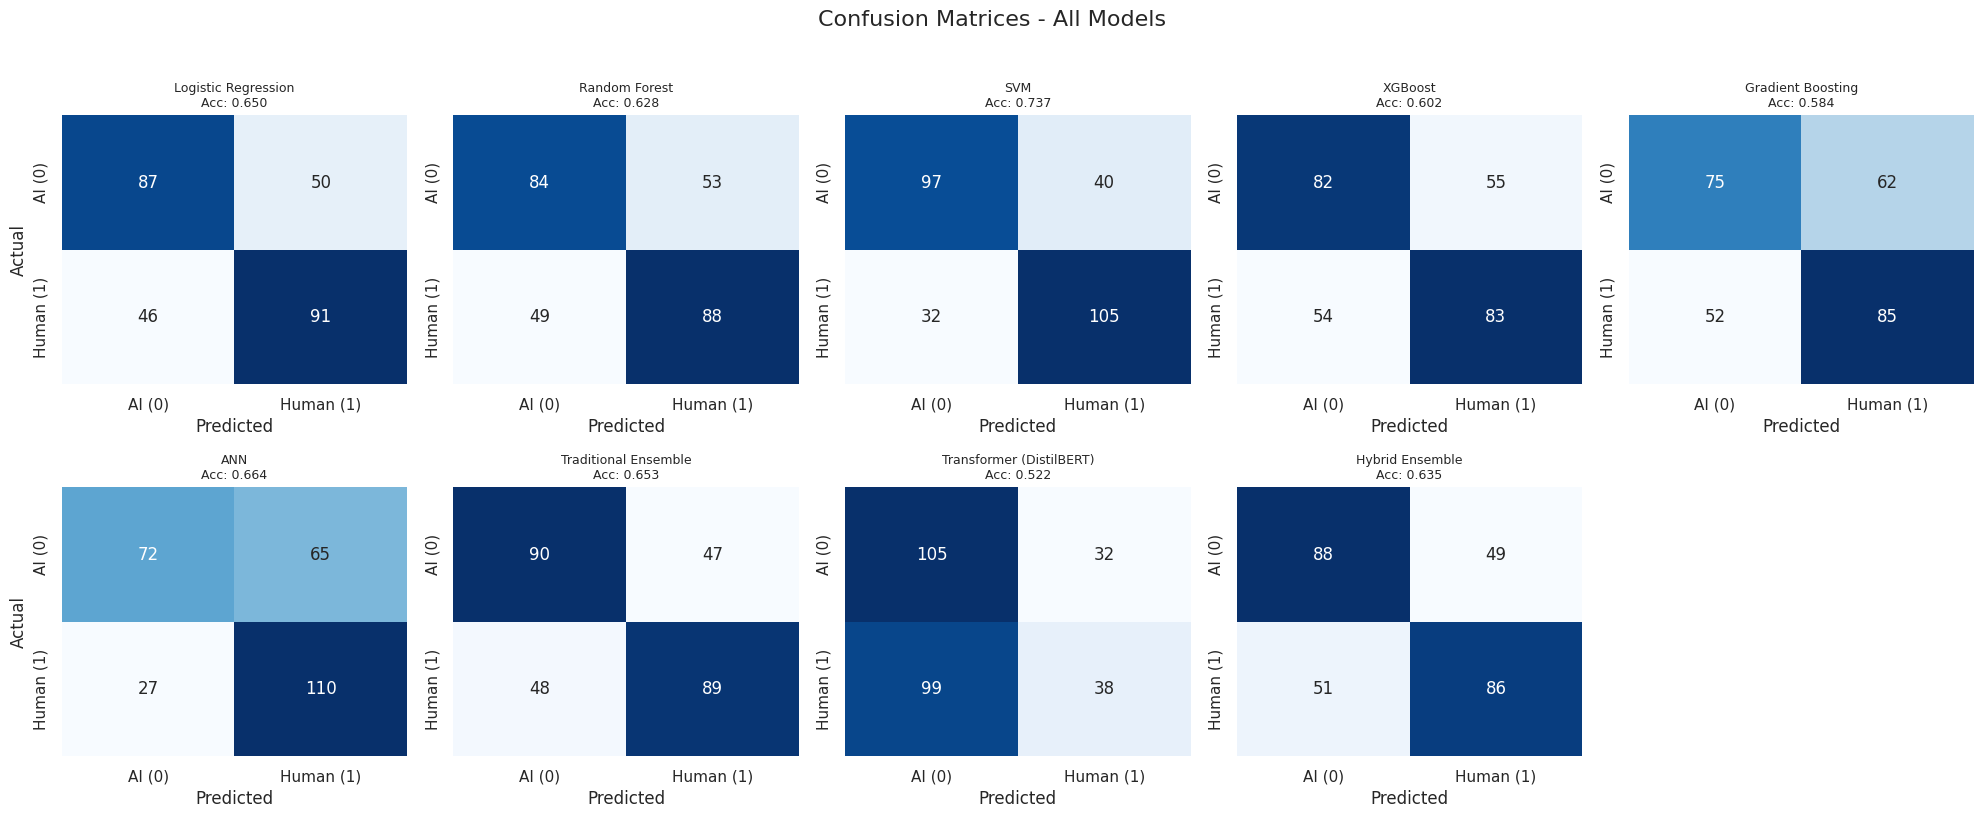

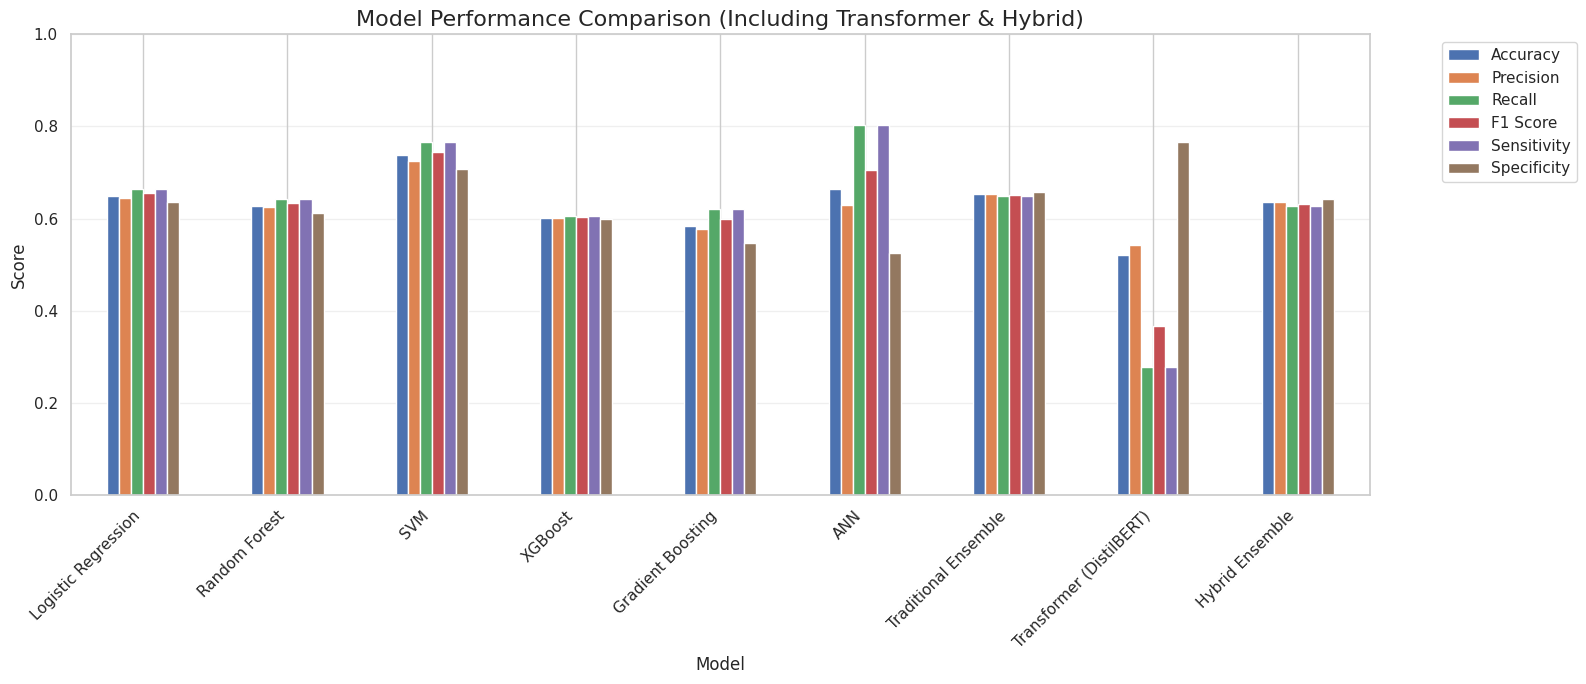


BEST MODEL: SVM
Accuracy: 0.7372
Precision: 0.7241
Recall: 0.7664
F1 Score: 0.7447


In [ ]:
# Model Visualization

# วาด Confusion Matrix
n_models = len(confusion_matrices)
n_cols = min(5, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['AI (0)', 'Human (1)'],
                yticklabels=['AI (0)', 'Human (1)'],
                ax=ax, cbar=False)
    ax.set_title(f'{name}\nAcc: {results[name][0]:.3f}', fontsize=9)
    ax.set_ylabel('Actual' if idx % n_cols == 0 else '')
    ax.set_xlabel('Predicted')

# ซ่อน subplot ที่เกินออกไป
for idx in range(len(confusion_matrices), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# เปรียบเทียบประสิทธิภาพของโมเดล
plt.figure(figsize=(16, 7))
results_df.plot(kind='bar', ax=plt.gca())
plt.title("Model Performance Comparison (Including Transformer & Hybrid)", fontsize=16)
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# โมเดลที่ดีที่สุด
best_model = results_df['Accuracy'].idxmax()
print(f"\n{'='*50}")
print(f"BEST MODEL: {best_model}")
print(f"{'='*50}")
print(f"Accuracy: {results_df.loc[best_model, 'Accuracy']:.4f}")
print(f"Precision: {results_df.loc[best_model, 'Precision']:.4f}")
print(f"Recall: {results_df.loc[best_model, 'Recall']:.4f}")
print(f"F1 Score: {results_df.loc[best_model, 'F1 Score']:.4f}")

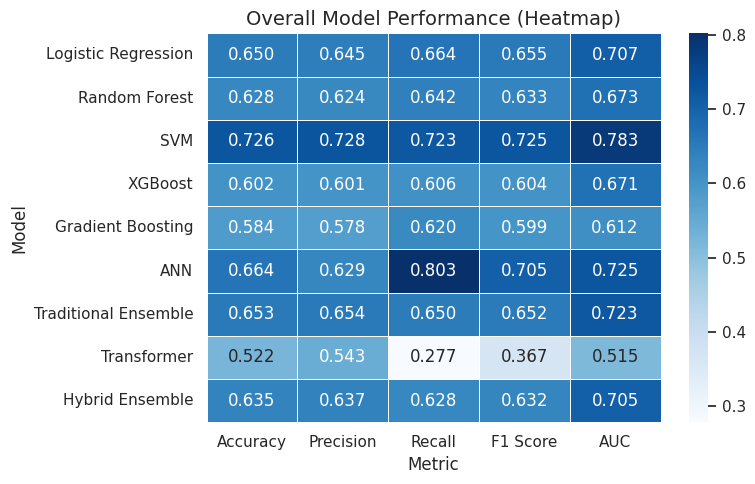

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

# สร้างตาราง metrics สำหรับทุกโมเดล (ไม่ใช้ results_main)
metric_rows = []

# โมเดลจาก models_to_evaluate (ยกเว้น Transformer / Hybrid)
for name, (model, is_ann, is_transformer, _) in models_to_evaluate.items():
    # ข้ามตัวที่เป็น Transformer หรือ Hybrid (เราจะเติมทีหลัง)
    if is_transformer or name == "Hybrid Ensemble":
        continue

    # ดึง probability ของคลาส 1 (Human)
    if is_ann:
        y_probs = model.predict(X_test, verbose=0).ravel()
    else:
        y_probs = model.predict_proba(X_test)[:, 1]

    # แปลงเป็น label ด้วย threshold 0.5
    y_pred = (y_probs >= 0.5).astype(int)

    # คำนวณ metric
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", zero_division=0
    )
    auc_score = roc_auc_score(y_test, y_probs)

    metric_rows.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC": auc_score
    })

# 2) เติม Transformer
y_pred_trans = (transformer_pred_probs >= 0.5).astype(int)
acc_trans = accuracy_score(y_test, y_pred_trans)
prec_trans, rec_trans, f1_trans, _ = precision_recall_fscore_support(
    y_test, y_pred_trans, average="binary", zero_division=0
)
auc_trans = roc_auc_score(y_test, transformer_pred_probs)

metric_rows.append({
    "Model": "Transformer",
    "Accuracy": acc_trans,
    "Precision": prec_trans,
    "Recall": rec_trans,
    "F1 Score": f1_trans,
    "AUC": auc_trans
})

# 3) เติม Hybrid Ensemble
y_pred_hybrid = (hybrid_probs >= 0.5).astype(int)
acc_hybrid = accuracy_score(y_test, y_pred_hybrid)
prec_hybrid, rec_hybrid, f1_hybrid, _ = precision_recall_fscore_support(
    y_test, y_pred_hybrid, average="binary", zero_division=0
)
auc_hybrid = roc_auc_score(y_test, hybrid_probs)

metric_rows.append({
    "Model": "Hybrid Ensemble",
    "Accuracy": acc_hybrid,
    "Precision": prec_hybrid,
    "Recall": rec_hybrid,
    "F1 Score": f1_hybrid,
    "AUC": auc_hybrid
})

# 4) แปลงเป็น DataFrame และวาด heatmap
metrics_df = pd.DataFrame(metric_rows).set_index("Model")

plt.figure(figsize=(8, 5))
sns.heatmap(
    metrics_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5
)
plt.title("Overall Model Performance (Heatmap)", fontsize=14)
plt.ylabel("Model")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()




**จัดอันดับโมเดลทั้งหมดตามค่า Accuracy**:

- ใช้ `results_df.sort_values('Accuracy', ascending=False)`  
  โดยเรียงโมเดลจาก Accuracy สูงสุดไปต่ำสุด
- วนลูปพิมพ์:
  - ลำดับอันดับ (1, 2, 3, …)
  - ชื่อโมเดล (`model_name`)
  - ค่า `Accuracy`
  - ค่า `F1 Score` ของแต่ละโมเดล (เผื่อดูสมดุล precision/recall)

ช่วยให้เห็นว่าโมเดลไหนทำได้ดีที่สุด และเทียบ F1 ไปพร้อมกัน

In [ ]:
print("MODEL RANKING BY ACCURACY:")
print("="*50)
ranking = results_df.sort_values('Accuracy', ascending=False)
for idx, (model_name, row) in enumerate(ranking.iterrows(), 1):
    print(f"{idx}. {model_name}: {row['Accuracy']:.4f} (F1: {row['F1 Score']:.4f})")

MODEL RANKING BY ACCURACY:
1. SVM: 0.7372 (F1: 0.7447)
2. ANN: 0.6642 (F1: 0.7051)
3. Traditional Ensemble: 0.6533 (F1: 0.6520)
4. Logistic Regression: 0.6496 (F1: 0.6547)
5. Hybrid Ensemble: 0.6350 (F1: 0.6324)
6. Random Forest: 0.6277 (F1: 0.6331)
7. XGBoost: 0.6022 (F1: 0.6036)
8. Gradient Boosting: 0.5839 (F1: 0.5986)
9. Transformer (DistilBERT): 0.5219 (F1: 0.3671)


**สรุปผลการประเมินโมเดล:**

ในการประเมินประสิทธิภาพของโมเดลสำหรับจำแนกข้อความ AI vs Human งานนี้เลือกใช้เมทริก Accuracy และ F1 Score เป็นเมทริกหลัก เนื่องจากทั้งสองตัวสามารถสะท้อนความแม่นยำโดยรวมของโมเดล และความสมดุลระหว่าง Precision และ Recall ได้อย่างเพียงพอสำหรับการเปรียบเทียบประสิทธิภาพในภาพรวมของโมเดลแต่ละตัว

จากการเปรียบเทียบค่า Accuracy และ F1 Score ของโมเดลทั้งหมด พบว่า SVM ให้ผลดีที่สุด โดยมี Accuracy ประมาณ 0.74 และ F1 Score ประมาณ 0.75 รองลงมาคือ ANN และ Logistic Regression ซึ่งอยู่ในระดับกลาง ส่วนโมเดลกลุ่ม Tree-based, Hybrid Ensemble และ Traditional Ensemble ให้ผลปานกลาง ขณะที่ Transformer (DistilBERT) ทำคะแนนได้ต่ำที่สุด



##ROC Curves



เปรียบเทียบความสามารถจำแนกของทุกโมเดล โดยดูว่าแต่ละโมเดลแยกคลาส 0/1 ได้ดีแค่ไหน โดยดูจากเส้นโค้งและค่า AUC

**ขั้นตอน:**

**1. Traditional ML Models**
   - วนทีละโมเดลใน `models_to_evaluate` (ยกเว้น Transformer และ Hybrid)
   - ถ้าเป็น ANN → ใช้ `model.predict(...).ravel()` เป็น probability  
   - ถ้าเป็นโมเดล sklearn → ใช้ `predict_proba(... )[:, 1]` เป็น probability ของคลาส 1  
   - คำนวณ `fpr, tpr` ด้วย `roc_curve(y_test, y_probs)`  
   - คำนวณ `AUC` ด้วย `auc(fpr, tpr)` และวาดเส้นบนกราฟ

**2. Transformer (DistilBERT)**
   - ใช้ `transformer_pred_probs` เป็น probability ของคลาส 1  
   - วาด ROC Curve ด้วยเส้นประ (`linestyle='--'`)

**3. Hybrid Ensemble**
   - ใช้ `hybrid_probs` (probability ที่ผสมจากหลายโมเดล)  
   - วาด ROC Curve ด้วยเส้นแบบ `-.`

**4. เส้นอ้างอิง Random Guess**
   - วาดเส้นทแยงจาก (0,0) ไป (1,1) เพื่อเปรียบเทียบกับการเดาสุ่ม


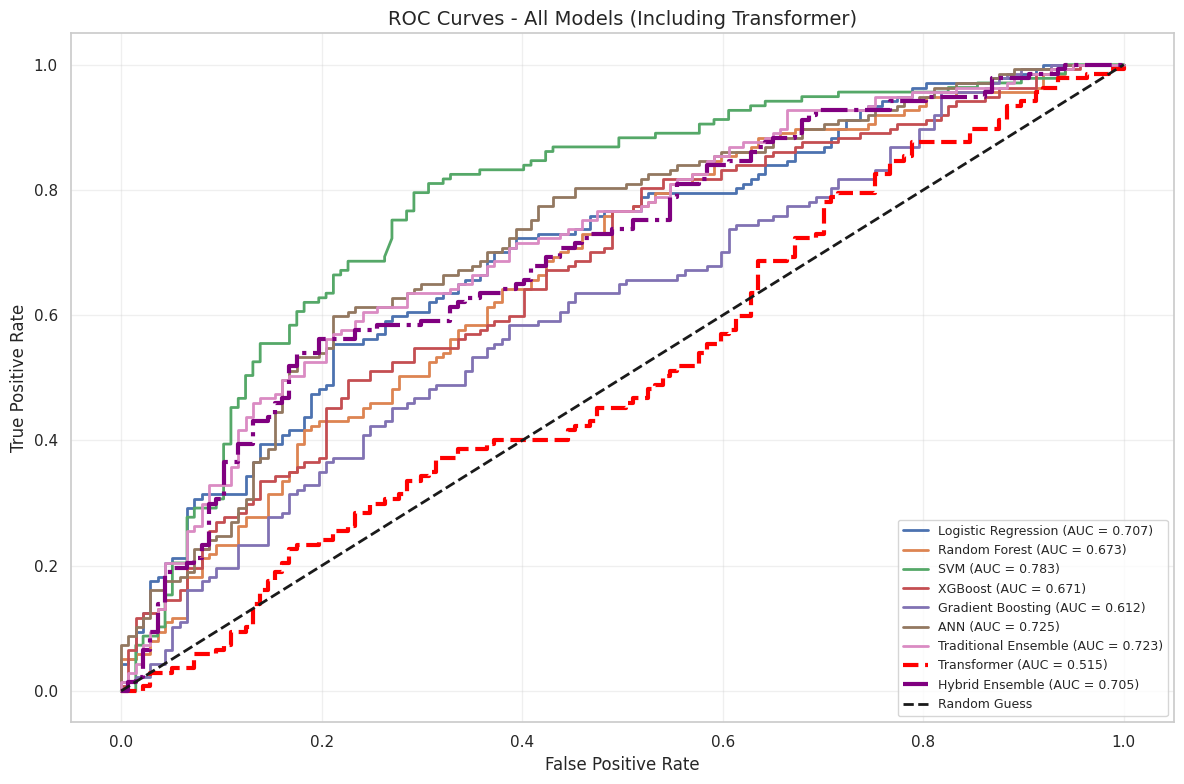

In [ ]:
# ROC CURVES

plt.figure(figsize=(12, 8))

# Traditional models
for name, (model, is_ann, is_transformer, _) in models_to_evaluate.items():
    if is_transformer or name == "Hybrid Ensemble":
        continue

    if is_ann:
        y_probs = model.predict(X_test, verbose=0).ravel()
    else:
        y_probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

# เพิ่ม Transformer ROC
fpr_trans, tpr_trans, _ = roc_curve(y_test, transformer_pred_probs)
roc_auc_trans = auc(fpr_trans, tpr_trans)
plt.plot(fpr_trans, tpr_trans, label=f'Transformer (AUC = {roc_auc_trans:.3f})',
         linewidth=3, linestyle='--', color='red')

# เพิ่ม Hybrid ROC
fpr_hybrid, tpr_hybrid, _ = roc_curve(y_test, hybrid_probs)
roc_auc_hybrid = auc(fpr_hybrid, tpr_hybrid)
plt.plot(fpr_hybrid, tpr_hybrid, label=f'Hybrid Ensemble (AUC = {roc_auc_hybrid:.3f})',
         linewidth=3, linestyle='-.', color='purple')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models (Including Transformer)', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**สรุปผลจาก ROC Curves:**

จากกราฟ ROC Curve พบว่า SVM เป็นโมเดลที่โดดเด่นที่สุด โดยมีเส้นโค้ง ROC สูงที่สุดและค่า AUC ประมาณ 0.78 ซึ่งบ่งบอกถึงความสามารถในการแยกข้อความมนุษย์และ AI ได้ดีที่สุด โมเดล ANN และ Traditional Ensemble ก็ให้ผลลัพธ์ดีเช่นกัน โดยมี AUC ประมาณ 0.72 แสดงถึงประสิทธิภาพที่ดีในระดับรองลงมา ส่วนโมเดลกลุ่ม tree-based เช่น Random Forest, XGBoost และ Gradient Boosting ให้ผลปานกลาง โดยมี AUC อยู่ในช่วง 0.61–0.67 ขณะที่ Hybrid Ensemble ทำงานได้ดีขึ้นกว่า Transformer เดี่ยว ๆ แต่ยังไม่ถึงระดับโมเดลที่ดีที่สุด ส่วน DistilBERT ทำผลงานต่ำที่สุด โดยมี AUC ประมาณ 0.51 ใกล้เคียงการสุ่มเดา สะท้อนว่าโมเดลยังไม่สามารถจับความต่างของข้อความได้ชัดเจน โดยสรุปแล้วทั้งจาก ROC และ AUC โมเดล SVM จำแนกได้ดีที่สุด

# Conclusion

จากผลการประเมินโมเดลทั้งหมด พบว่า SVM เป็นโมเดลที่มีประสิทธิภาพดีที่สุด สำหรับงานจำแนกข้อความมนุษย์และ AI โดยให้ค่า Accuracy, F1 Score และ AUC สูงที่สุดเมื่อเทียบกับโมเดลอื่น แสดงให้เห็นว่า SVM สามารถจับความแตกต่างของรูปแบบภาษาและลักษณะการเขียนได้อย่างแม่นยำ จึงเหมาะที่จะเลือกใช้เป็นโมเดลหลักของโปรเจกต์นี้ในการทำนายว่าข้อความถูกสร้างโดยมนุษย์หรือ AI

# Members

1. ณัฐชยา ฤทธิรุณ 6624650237
2. ธัญวรัตน์ พระคำยาน
6624650286
3. นงนภัส สุนนทะนาม
6624650302
4. พิมพ์ลดา งามประดับเลิศ 6624650377
5. ลีเวย์ อึ้ง
6624650468
6. อนุภัทร สุทธิเลิศ
6624650526